In [1]:
import os
import numpy as np
import pandas as pd

# Setup: Common electrode set (after mapping)
common_electrodes_base = [
    'C3', 'C4', 'Cz', 'F3', 'F4', 'F7', 'F8', 'Fp1', 'Fp2', 'Fpz',
    'Fz', 'O1', 'O2', 'Oz', 'P3', 'P4', 'P7', 'P8', 'Pz', 'T7', 'T8'
]
common_electrodes_base = [
    'C3', 'C4', 'Cz', 'F3', 'F4', 'F7', 'F8', 'Fp1', 'Fp2', 
    'Fz', 'O1', 'O2',  'P3', 'P4', 'P7', 'P8', 'Pz', 'T7', 'T8'
]
# Mapping for 10-20 to 10-10
electrode_map_10_20_to_10_10 = {
    'T3': 'T7',
    'T4': 'T8',
    'T5': 'P7',
    'T6': 'P8'
}

# Replace with your actual variables

# Load files
direct = "C:/EEG_vicon_rest"
files = [os.path.join(direct, file) for file in os.listdir(direct) if file.endswith(".parquet")]
files = sorted(files)

win_size = 3000  # Minimum number of samples

# Helper: compute FC matrix using Pearson correlation
def connectivity_matrix(data_dict, electrodes):
    signals = [data_dict[e] for e in electrodes]
    matrix = np.corrcoef(signals)
    return matrix

# Initialize
subject_rest_data = []
subject_block_data = []
subject_fix_data = []
valid_electrodes_global = set(common_electrodes_base)

for filename in files:
    print(f"📂 Processing: {os.path.basename(filename)}")
    df = pd.read_parquet(filename)

    # Remap column names if needed
    remapped_cols = {
        col: electrode_map_10_20_to_10_10[col]
        for col in df.columns if col in electrode_map_10_20_to_10_10
    }
    df = df.rename(columns=remapped_cols)

    # Keep only electrodes present in this file
    electrodes = [e for e in common_electrodes_base if e in df.columns]

    fc_rest = {}
    fc_block = {}
    fc_fix = {}
    valid_electrodes_all = None

    for i in range(1, 10):
        df_rest = df.query(f'PERIODE == "REST{i}"')
        df_block = df.query(f'BLOCK == {i}')
        df_fix = df.query(f'PERIODE == "preFIX{i}"')

        data_rest = {}
        data_block = {}
        data_fix = {}
        valid_electrodes = []

        for elec in electrodes:
            sig_rest = df_rest[elec].dropna().values[:win_size]
            sig_block = df_block[elec].dropna().values[:win_size]
            sig_fix = df_fix[elec].dropna().values[:win_size]

            if len(sig_rest) < win_size or len(sig_block) < win_size or len(sig_fix) < win_size:
                print(f'⚠️ short signal in block {i}:', elec)
                continue

            data_rest[elec] = sig_rest
            data_block[elec] = sig_block
            data_fix[elec] = sig_fix
            valid_electrodes.append(elec)

        if len(valid_electrodes) < 2:
            print(f"⚠️ Too few electrodes for FC in block {i}")
            continue

        fc_rest[i] = connectivity_matrix(data_rest, valid_electrodes)
        fc_block[i] = connectivity_matrix(data_block, valid_electrodes)
        fc_fix[i] = connectivity_matrix(data_fix, valid_electrodes)

        if valid_electrodes_all is None:
            valid_electrodes_all = set(valid_electrodes)
        else:
            valid_electrodes_all &= set(valid_electrodes)

    valid_electrodes_all = sorted(list(valid_electrodes_all))
    valid_electrodes_global &= set(valid_electrodes_all)

    # Create tensors: (n_electrodes, n_electrodes, 9 blocks)
    try:
        rest_tensor = np.stack([fc_rest[b] for b in range(1, 10)], axis=2)
        block_tensor = np.stack([fc_block[b] for b in range(1, 10)], axis=2)
        fix_tensor = np.stack([fc_fix[b] for b in range(1, 10)], axis=2)
    except Exception as e:
        print(f"❌ Skipping file {filename} due to missing data in some blocks.")
        continue

    subject_rest_data.append(rest_tensor)
    subject_block_data.append(block_tensor)
    subject_fix_data.append(fix_tensor)

# Harmonize electrode sets across all subjects
valid_electrodes_global = sorted(list(valid_electrodes_global))
print(f"\n✅ Electrodes valid for ALL subjects: {valid_electrodes_global}")

n_subjects = len(subject_rest_data)
n_electrodes = len(valid_electrodes_global)

# Stack across subjects: shape = (n_subjects, n_electrodes, n_electrodes, 9)
rest_all = np.stack(subject_rest_data)
block_all = np.stack(subject_block_data)
fix_all = np.stack(subject_fix_data)

# Final report
print(f"\n✅ FC data shape: {rest_all.shape} (subjects, electrodes, electrodes, blocks)")


C:\Users\Peter\anaconda3\lib\site-packages\pandas\core\arrays\masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


📂 Processing: DF_SYNCHRO_EEG_RESTFIXBLOCK_Adrien.parquet
📂 Processing: DF_SYNCHRO_EEG_RESTFIXBLOCK_Ana.parquet
📂 Processing: DF_SYNCHRO_EEG_RESTFIXBLOCK_Antoine.parquet
📂 Processing: DF_SYNCHRO_EEG_RESTFIXBLOCK_Camila.parquet
📂 Processing: DF_SYNCHRO_EEG_RESTFIXBLOCK_Charlene.parquet
📂 Processing: DF_SYNCHRO_EEG_RESTFIXBLOCK_Denis.parquet
📂 Processing: DF_SYNCHRO_EEG_RESTFIXBLOCK_Denis2.parquet
📂 Processing: DF_SYNCHRO_EEG_RESTFIXBLOCK_Ko.parquet
📂 Processing: DF_SYNCHRO_EEG_RESTFIXBLOCK_Louise.parquet
📂 Processing: DF_SYNCHRO_EEG_RESTFIXBLOCK_Mael.parquet
📂 Processing: DF_SYNCHRO_EEG_RESTFIXBLOCK_Patrice.parquet
📂 Processing: DF_SYNCHRO_EEG_RESTFIXBLOCK_Pauline.parquet
📂 Processing: DF_SYNCHRO_EEG_RESTFIXBLOCK_Pierre.parquet
📂 Processing: DF_SYNCHRO_EEG_RESTFIXBLOCK_Sophie.parquet
📂 Processing: DF_SYNCHRO_EEG_RESTFIXBLOCK_Vincent.parquet
📂 Processing: DF_SYNCHRO_EEG_RESTFIXBLOCK_Yuki.parquet
📂 Processing: DF_SYNCHRO_EEG_RESTFIXBLOCK_Yuyang.parquet
📂 Processing: DF_SYNCHRO_EEG_RESTFIXB

C:\Users\Peter\anaconda3\lib\site-packages\seaborn\utils.py:80: UserWarning: Glyph 129504 (\N{BRAIN}) missing from current font.
  fig.canvas.draw()
C:\Users\Peter\anaconda3\lib\site-packages\seaborn\utils.py:80: UserWarning: Glyph 129504 (\N{BRAIN}) missing from current font.
  fig.canvas.draw()
C:\Users\Peter\AppData\Local\Temp\ipykernel_33172\1885331492.py:30: UserWarning: Glyph 129504 (\N{BRAIN}) missing from current font.
  plt.tight_layout(rect=[0, 0, 1, 0.95])  # leave space for suptitle
C:\Users\Peter\anaconda3\lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 129504 (\N{BRAIN}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


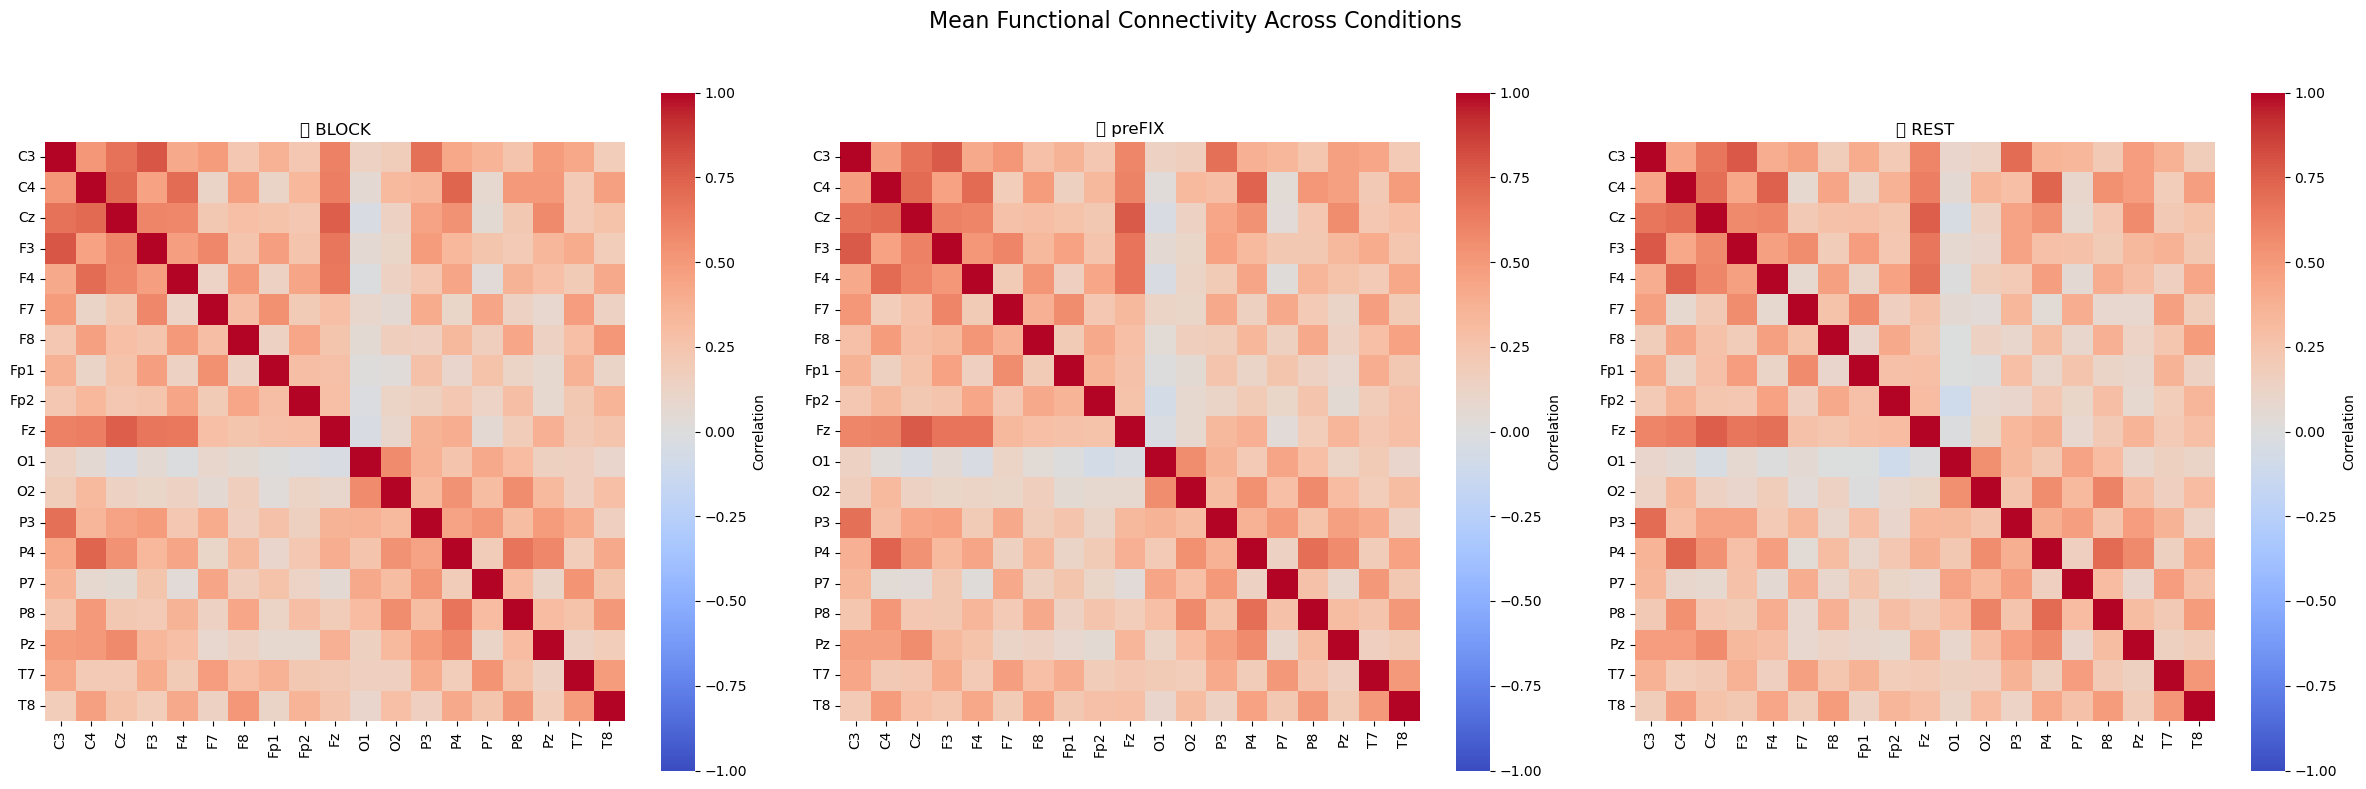

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

def compute_mean_fc(fc_data):
    """Average across subjects and blocks: (subjects, electrodes, electrodes, blocks) → (electrodes, electrodes)"""
    return np.nanmean(fc_data, axis=(0, 3))

# Compute average FC matrices
mean_block = compute_mean_fc(block_all)
mean_fix = compute_mean_fc(fix_all)
mean_rest = compute_mean_fc(rest_all)

# Define global color scale
vmin, vmax = -1.0, 1.0
labels = valid_electrodes_global

# Plot all three heatmaps side by side
fig, axs = plt.subplots(1, 3, figsize=(24, 8))

for ax, fc, title in zip(axs, [mean_block, mean_fix, mean_rest],
                         ["🧠 BLOCK", "🧠 preFIX", "🧠 REST"]):
    sns.heatmap(fc, ax=ax, xticklabels=labels, yticklabels=labels,
                cmap="coolwarm", vmin=vmin, vmax=vmax,
                square=True, cbar_kws={'label': 'Correlation'})
    ax.set_title(title)
    ax.tick_params(axis='x', rotation=90)
    ax.tick_params(axis='y', rotation=0)

plt.suptitle("Mean Functional Connectivity Across Conditions", fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.95])  # leave space for suptitle
plt.show()


In [3]:
def min_max_off_diagonal(matrix):
    """Return min and max of matrix, excluding the diagonal."""
    mask = ~np.eye(matrix.shape[0], dtype=bool)
    values = matrix[mask]
    return np.min(values), np.max(values)

# Compute average FC matrices
mean_block = compute_mean_fc(block_all)
mean_fix = compute_mean_fc(fix_all)
mean_rest = compute_mean_fc(rest_all)

# Print min/max excluding diagonal
min_b, max_b = min_max_off_diagonal(mean_block)
min_f, max_f = min_max_off_diagonal(mean_fix)
min_r, max_r = min_max_off_diagonal(mean_rest)

print(f"📈 BLOCK FC (off-diagonal): min = {min_b:.3f}, max = {max_b:.3f}")
print(f"📈 preFIX FC (off-diagonal): min = {min_f:.3f}, max = {max_f:.3f}")
print(f"📈 REST FC (off-diagonal): min = {min_r:.3f}, max = {max_r:.3f}")


📈 BLOCK FC (off-diagonal): min = -0.036, max = 0.789
📈 preFIX FC (off-diagonal): min = -0.071, max = 0.769
📈 REST FC (off-diagonal): min = -0.095, max = 0.775


In [31]:
print(electrodes)

['C3', 'C4', 'Cz', 'F3', 'F4', 'F7', 'F8', 'Fp1', 'Fp2', 'Fz', 'O1', 'O2', 'P3', 'P4', 'P7', 'P8', 'Pz', 'T7', 'T8']


In [4]:
print(block_all.shape)  # (18, 19, 19, 9)
print(fix_all.shape)    # ? — should be (18, 19, 19, 9)
print(rest_all.shape)   # ? — should be (18, 19, 19, 9)


(18, 19, 19, 9)
(18, 19, 19, 9)
(18, 19, 19, 9)


In [5]:
print("rest_all shape:", rest_all.shape)
print("fix_all shape:", fix_all.shape)
print("block_all shape:", block_all.shape)


rest_all shape: (18, 19, 19, 9)
fix_all shape: (18, 19, 19, 9)
block_all shape: (18, 19, 19, 9)


In [6]:
np.save("rest_all_fc.npy",rest_all)
np.save("fix_all_fc.npy",fix_all)
np.save("block_all_fc.npy",block_all)

In [7]:
import numpy as np
from scipy.stats import pearsonr, wilcoxon

# Load your precomputed arrays (adjust paths/names if needed)

spec_rest_all = np.load("spec_rest_all.npy")  # shape: (subjects, electrodes, blocks)
spec_fix_all = np.load("spec_fix_all.npy")
spec_block_all = np.load("spec_block_all.npy")

auc_rest_all = np.load("auc_rest_all.npy")  # shape: (subjects, electrodes, blocks)
auc_fix_all = np.load("auc_fix_all.npy")
auc_block_all = np.load("auc_block_all.npy")

# --------------------------------------------
def mean_fc_strength(fc_array):
    """
    Compute mean functional connectivity strength per electrode,
    averaging over edges (connected electrodes) and blocks.
    fc_array shape: (subjects, electrodes, electrodes, blocks)
    Returns: (subjects, electrodes)
    """
    return np.nanmean(fc_array, axis=(2, 3))

def mean_timescale(ts_array):
    """
    Average intrinsic timescale per electrode,
    averaging over blocks.
    ts_array shape: (subjects, electrodes, blocks)
    Returns: (subjects, electrodes)
    """
    return np.nanmean(ts_array, axis=2)

def correlate_fc_timescale(fc_strength, ts_values):
    """
    For each electrode, compute Pearson correlation across subjects between
    FC strength and timescale values.
    fc_strength and ts_values shape: (subjects, electrodes)
    Returns:
        r_vals: correlation coefficients (electrodes,)
        p_vals: p-values (electrodes,)
        wilcoxon_stat: Wilcoxon test statistic comparing correlations to zero
        wilcoxon_p: Wilcoxon test p-value
    """
    n_electrodes = fc_strength.shape[1]
    r_vals = np.zeros(n_electrodes)
    p_vals = np.zeros(n_electrodes)

    for e in range(n_electrodes):
        r, p = pearsonr(fc_strength[:, e], ts_values[:, e])
        r_vals[e] = r
        p_vals[e] = p

    # Test if the distribution of correlations differs from zero
    wilcoxon_stat, wilcoxon_p = wilcoxon(r_vals)

    return r_vals, p_vals, wilcoxon_stat, wilcoxon_p

# --------------------------------------------
# Compute mean FC strength for each condition
fc_rest_strength = mean_fc_strength(rest_all)
fc_fix_strength = mean_fc_strength(fix_all)
fc_block_strength = mean_fc_strength(block_all)

# Compute mean intrinsic timescales for each condition and metric
auc_rest_strength = mean_timescale(auc_rest_all)
auc_fix_strength = mean_timescale(auc_fix_all)
auc_block_strength = mean_timescale(auc_block_all)

spec_rest_strength = mean_timescale(spec_rest_all)
spec_fix_strength = mean_timescale(spec_fix_all)
spec_block_strength = mean_timescale(spec_block_all)

# --------------------------------------------
# Correlations between FC and AUC timescale
r_rest_auc, p_rest_auc, w_stat_rest_auc, w_p_rest_auc = correlate_fc_timescale(fc_rest_strength, auc_rest_strength)
r_fix_auc, p_fix_auc, w_stat_fix_auc, w_p_fix_auc = correlate_fc_timescale(fc_fix_strength, auc_fix_strength)
r_block_auc, p_block_auc, w_stat_block_auc, w_p_block_auc = correlate_fc_timescale(fc_block_strength, auc_block_strength)

# Correlations between FC and spectral slope timescale
r_rest_spec, p_rest_spec, w_stat_rest_spec, w_p_rest_spec = correlate_fc_timescale(fc_rest_strength, spec_rest_strength)
r_fix_spec, p_fix_spec, w_stat_fix_spec, w_p_fix_spec = correlate_fc_timescale(fc_fix_strength, spec_fix_strength)
r_block_spec, p_block_spec, w_stat_block_spec, w_p_block_spec = correlate_fc_timescale(fc_block_strength, spec_block_strength)

# --------------------------------------------
# Print summary of Wilcoxon tests for each condition & metric
print("Wilcoxon signed-rank test for correlations (testing if median r differs from zero):")
print(f"REST - AUC: statistic={w_stat_rest_auc}, p-value={w_p_rest_auc}")
print(f"preFIX - AUC: statistic={w_stat_fix_auc}, p-value={w_p_fix_auc}")
print(f"BLOCK - AUC: statistic={w_stat_block_auc}, p-value={w_p_block_auc}")

print(f"REST - Spectral slope: statistic={w_stat_rest_spec}, p-value={w_p_rest_spec}")
print(f"preFIX - Spectral slope: statistic={w_stat_fix_spec}, p-value={w_p_fix_spec}")
print(f"BLOCK - Spectral slope: statistic={w_stat_block_spec}, p-value={w_p_block_spec}")

# Optionally, inspect electrode-wise correlations (r_vals)
# Example: print correlation for first 5 electrodes in REST AUC condition
print("\nExample correlations REST condition (FC vs AUC) for first 5 electrodes:")
for i in range(min(5, len(r_rest_auc))):
    print(f"Electrode {i}: r={r_rest_auc[i]:.3f}, p={p_rest_auc[i]:.3g}")


Wilcoxon signed-rank test for correlations (testing if median r differs from zero):
REST - AUC: statistic=20.0, p-value=0.00141143798828125
preFIX - AUC: statistic=54.0, p-value=0.104156494140625
BLOCK - AUC: statistic=70.0, p-value=0.3320655822753906
REST - Spectral slope: statistic=15.0, p-value=0.000522613525390625
preFIX - Spectral slope: statistic=62.0, p-value=0.1956329345703125
BLOCK - Spectral slope: statistic=90.0, p-value=0.8595733642578125

Example correlations REST condition (FC vs AUC) for first 5 electrodes:
Electrode 0: r=-0.247, p=0.324
Electrode 1: r=-0.201, p=0.423
Electrode 2: r=-0.324, p=0.19
Electrode 3: r=-0.463, p=0.053
Electrode 4: r=-0.336, p=0.173


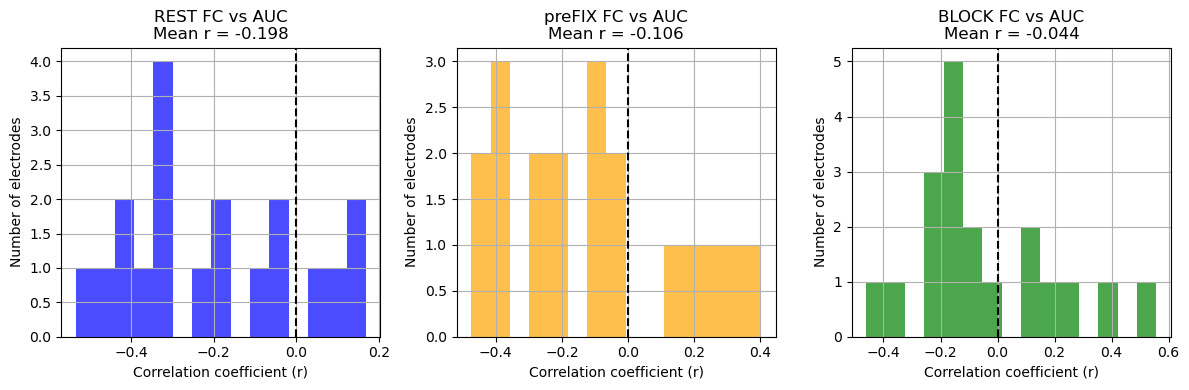

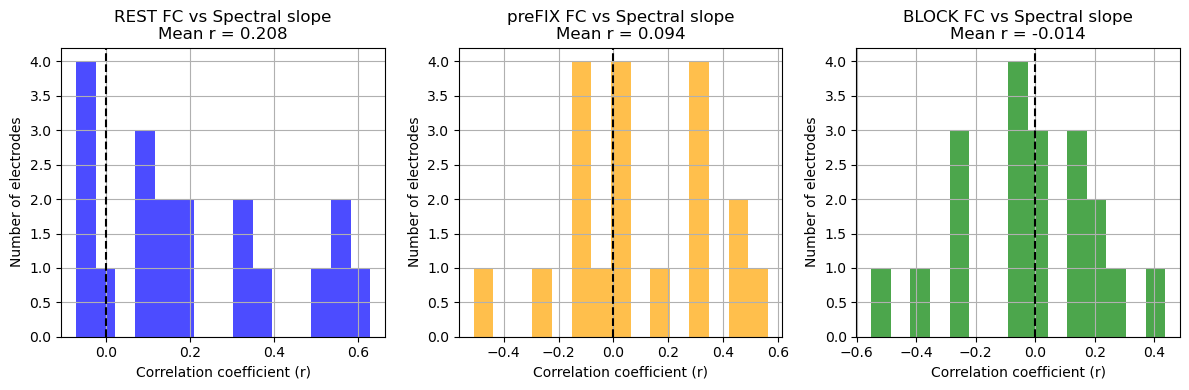

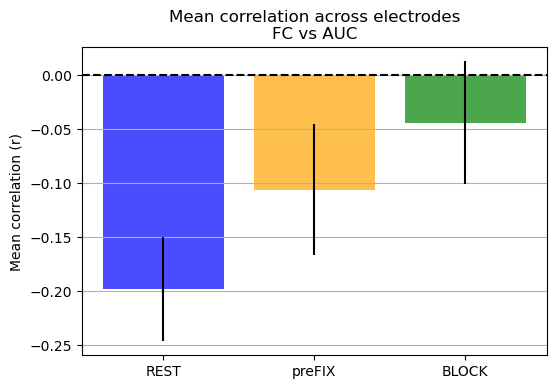

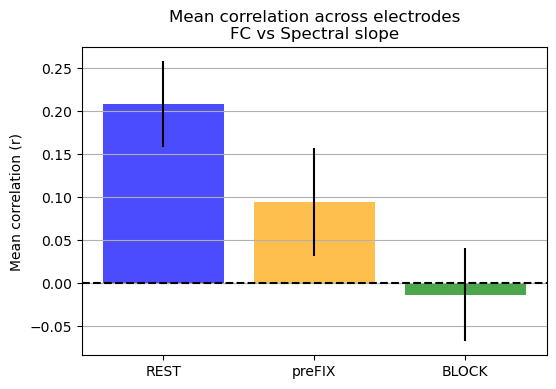

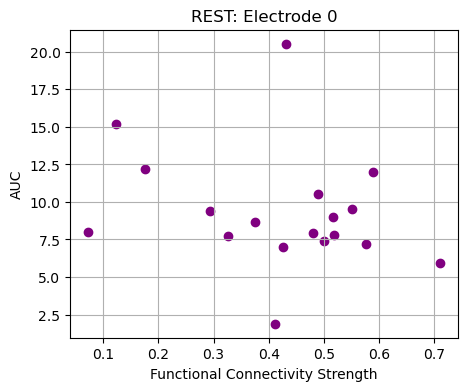

In [8]:
import matplotlib.pyplot as plt

def plot_correlation_histograms(r_vals_dict, title_suffix):
    """
    Plot histograms of correlation coefficients for each condition.
    
    r_vals_dict: dict with keys 'REST', 'preFIX', 'BLOCK' and values correlation arrays
    title_suffix: str, e.g., 'FC vs AUC' or 'FC vs Spectral slope'
    """
    plt.figure(figsize=(12, 4))
    conditions = ['REST', 'preFIX', 'BLOCK']
    colors = ['blue', 'orange', 'green']

    for i, cond in enumerate(conditions):
        plt.subplot(1, 3, i+1)
        r_vals = r_vals_dict[cond]
        plt.hist(r_vals, bins=15, color=colors[i], alpha=0.7)
        plt.title(f"{cond} {title_suffix}\nMean r = {np.mean(r_vals):.3f}")
        plt.xlabel("Correlation coefficient (r)")
        plt.ylabel("Number of electrodes")
        plt.axvline(0, color='black', linestyle='--')
        plt.grid(True)

    plt.tight_layout()
    plt.show()

def plot_mean_correlation_bar(r_vals_dict, title_suffix):
    """
    Plot bar chart of mean correlations with error bars for each condition.
    
    r_vals_dict: dict with keys 'REST', 'preFIX', 'BLOCK' and values correlation arrays
    """
    conditions = ['REST', 'preFIX', 'BLOCK']
    means = [np.mean(r_vals_dict[c]) for c in conditions]
    sems = [np.std(r_vals_dict[c]) / np.sqrt(len(r_vals_dict[c])) for c in conditions]

    plt.figure(figsize=(6,4))
    plt.bar(conditions, means, yerr=sems, color=['blue','orange','green'], alpha=0.7)
    plt.title(f"Mean correlation across electrodes\n{title_suffix}")
    plt.ylabel("Mean correlation (r)")
    plt.axhline(0, color='black', linestyle='--')
    plt.grid(axis='y')
    plt.show()

def plot_example_scatter(fc_strength, ts_values, electrode_idx, condition_name, metric_name):
    """
    Scatter plot of FC strength vs timescale for one electrode across subjects.
    """
    plt.figure(figsize=(5,4))
    plt.scatter(fc_strength[:, electrode_idx], ts_values[:, electrode_idx], color='purple')
    plt.xlabel('Functional Connectivity Strength')
    plt.ylabel(f'{metric_name}')
    plt.title(f'{condition_name}: Electrode {electrode_idx}')
    plt.grid(True)
    plt.show()


# Prepare dicts for plotting
r_vals_auc = {
    'REST': r_rest_auc,
    'preFIX': r_fix_auc,
    'BLOCK': r_block_auc
}

r_vals_spec = {
    'REST': r_rest_spec,
    'preFIX': r_fix_spec,
    'BLOCK': r_block_spec
}

# Plot histograms
plot_correlation_histograms(r_vals_auc, 'FC vs AUC')
plot_correlation_histograms(r_vals_spec, 'FC vs Spectral slope')

# Plot mean correlation bar plots
plot_mean_correlation_bar(r_vals_auc, 'FC vs AUC')
plot_mean_correlation_bar(r_vals_spec, 'FC vs Spectral slope')

# Plot scatter for example electrode (e.g. electrode 0) in REST condition, AUC metric
plot_example_scatter(fc_rest_strength, auc_rest_strength, electrode_idx=0, condition_name='REST', metric_name='AUC')


Friedman test: χ² = 1.444, p = 0.48567

Pairwise comparisons (Wilcoxon signed-rank):
REST vs preFIX:      W = 71.0, p = 0.55087
preFIX vs BLOCK:     W = 77.0, p = 0.73373
REST vs BLOCK:       W = 69.0, p = 0.49508


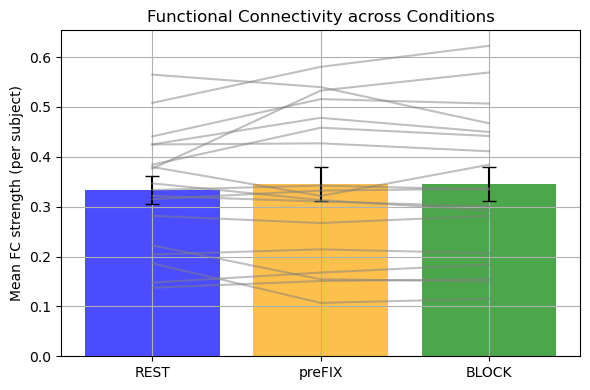

In [9]:
from scipy.stats import friedmanchisquare, wilcoxon
import matplotlib.pyplot as plt

# Assume these are (subjects, electrodes)
fc_rest_strength = mean_fc_strength(rest_all)
fc_fix_strength = mean_fc_strength(fix_all)
fc_block_strength = mean_fc_strength(block_all)

# Average over electrodes → (subjects,)
fc_rest_mean = np.mean(fc_rest_strength, axis=1)
fc_fix_mean = np.mean(fc_fix_strength, axis=1)
fc_block_mean = np.mean(fc_block_strength, axis=1)

# --- Friedman test (non-parametric repeated-measures ANOVA)
friedman_stat, friedman_p = friedmanchisquare(fc_rest_mean, fc_fix_mean, fc_block_mean)
print(f"Friedman test: χ² = {friedman_stat:.3f}, p = {friedman_p:.5f}")

# --- Pairwise Wilcoxon tests (post-hoc)
w1, p1 = wilcoxon(fc_rest_mean, fc_fix_mean)
w2, p2 = wilcoxon(fc_fix_mean, fc_block_mean)
w3, p3 = wilcoxon(fc_rest_mean, fc_block_mean)

print("\nPairwise comparisons (Wilcoxon signed-rank):")
print(f"REST vs preFIX:      W = {w1}, p = {p1:.5f}")
print(f"preFIX vs BLOCK:     W = {w2}, p = {p2:.5f}")
print(f"REST vs BLOCK:       W = {w3}, p = {p3:.5f}")

# --- Visualization
means = [np.mean(fc_rest_mean), np.mean(fc_fix_mean), np.mean(fc_block_mean)]
sems = [np.std(fc_rest_mean)/np.sqrt(len(fc_rest_mean)),
        np.std(fc_fix_mean)/np.sqrt(len(fc_fix_mean)),
        np.std(fc_block_mean)/np.sqrt(len(fc_block_mean))]

plt.figure(figsize=(6, 4))
x = ['REST', 'preFIX', 'BLOCK']
plt.bar(x, means, yerr=sems, capsize=5, alpha=0.7, color=['blue', 'orange', 'green'])

# Overlay individual subject lines
for i in range(fc_rest_mean.shape[0]):
    plt.plot(x, [fc_rest_mean[i], fc_fix_mean[i], fc_block_mean[i]], color='gray', alpha=0.5)

plt.ylabel('Mean FC strength (per subject)')
plt.title('Functional Connectivity across Conditions')
plt.grid(True)
plt.tight_layout()
plt.show()


In [10]:
from scipy.stats import f_oneway
import statsmodels.api as sm
from statsmodels.stats.anova import AnovaRM
import pandas as pd

n_subjects, n_electrodes = fc_rest_strength.shape

# Prepare long-form DataFrame
df_long = pd.DataFrame({
    'Subject': np.repeat(np.arange(n_subjects), 3),
    'Condition': np.tile(['REST', 'preFIX', 'BLOCK'], n_subjects),
    # Flatten electrode values across subjects
    'Electrode_0': np.concatenate([fc_rest_strength[:, 0], fc_fix_strength[:, 0], fc_block_strength[:, 0]]),
    'Electrode_1': np.concatenate([fc_rest_strength[:, 1], fc_fix_strength[:, 1], fc_block_strength[:, 1]]),
    # repeat for all electrodes...
})

# Or loop over electrodes:
p_vals = []
for e in range(n_electrodes):
    # Create per-electrode long-form dataframe
    df_e = pd.DataFrame({
        'Subject': np.arange(n_subjects).repeat(3),
        'Condition': ['REST', 'preFIX', 'BLOCK'] * n_subjects,
        'FC': np.concatenate([
            fc_rest_strength[:, e],
            fc_fix_strength[:, e],
            fc_block_strength[:, e],
        ])
    })

    # Run repeated measures ANOVA
    aovrm = AnovaRM(df_e, 'FC', 'Subject', within=['Condition'])
    res = aovrm.fit()
    p_val = res.anova_table['Pr > F'].values[0]
    p_vals.append(p_val)

# Multiple comparisons correction
from statsmodels.stats.multitest import fdrcorrection
significant, pvals_corrected = fdrcorrection(p_vals, alpha=0.05)

# Report
print("Significant electrodes after FDR correction:")
for i, sig in enumerate(significant):
    if sig:
        print(f"Electrode {i}: p = {pvals_corrected[i]:.4f}")


Significant electrodes after FDR correction:
Electrode 8: p = 0.0174
Electrode 17: p = 0.0429
Electrode 18: p = 0.0174


In [11]:
def flatten_upper_tri(matrix):
    """Flatten the upper triangle of a symmetric matrix (excluding diagonal)."""
    return matrix[np.triu_indices(matrix.shape[0], k=1)]

# Compute mean FC across subjects and blocks
mean_rest_fc = np.nanmean(rest_all, axis=(0, 3))   # shape (19, 19)
mean_fix_fc = np.nanmean(fix_all, axis=(0, 3))
mean_block_fc = np.nanmean(block_all, axis=(0, 3))

# Flatten upper triangles
vec_rest = flatten_upper_tri(mean_rest_fc)
vec_fix = flatten_upper_tri(mean_fix_fc)
vec_block = flatten_upper_tri(mean_block_fc)

# Correlations
from scipy.stats import pearsonr

r_rest_block, p_rb = pearsonr(vec_rest, vec_block)
r_rest_fix, p_rf = pearsonr(vec_rest, vec_fix)
r_fix_block, p_fb = pearsonr(vec_fix, vec_block)

print(f"REST vs BLOCK: r = {r_rest_block:.3f}, p = {p_rb:.3g}")
print(f"REST vs preFIX: r = {r_rest_fix:.3f}, p = {p_rf:.3g}")
print(f"preFIX vs BLOCK: r = {r_fix_block:.3f}, p = {p_fb:.3g}")


REST vs BLOCK: r = 0.988, p = 1.21e-139
REST vs preFIX: r = 0.979, p = 3.12e-118
preFIX vs BLOCK: r = 0.987, p = 4.58e-137


In [12]:
r_rest_block_all = []
r_rest_fix_all = []
r_fix_block_all = []

for subj in range(rest_all.shape[0]):
    # Average over blocks
    fc_rest = np.nanmean(rest_all[subj], axis=2)
    fc_fix = np.nanmean(fix_all[subj], axis=2)
    fc_block = np.nanmean(block_all[subj], axis=2)
    
    v_rest = flatten_upper_tri(fc_rest)
    v_fix = flatten_upper_tri(fc_fix)
    v_block = flatten_upper_tri(fc_block)

    r_rest_block_all.append(pearsonr(v_rest, v_block)[0])
    r_rest_fix_all.append(pearsonr(v_rest, v_fix)[0])
    r_fix_block_all.append(pearsonr(v_fix, v_block)[0])

# Group-level stats
from scipy.stats import ttest_rel
print("Repeated correlation across subjects:")
print("REST vs BLOCK:", ttest_rel(r_rest_block_all, r_rest_fix_all))
print("REST vs preFIX:", ttest_rel(r_rest_fix_all, r_fix_block_all))
print("preFIX vs BLOCK:", ttest_rel(r_fix_block_all, r_rest_block_all))


Repeated correlation across subjects:
REST vs BLOCK: TtestResult(statistic=0.6011199364445513, pvalue=0.5556913795889202, df=17)
REST vs preFIX: TtestResult(statistic=-2.5454947853651038, pvalue=0.020902681566089713, df=17)
preFIX vs BLOCK: TtestResult(statistic=2.311623649855985, pvalue=0.033597690675473975, df=17)


In [13]:
import statsmodels.formula.api as smf

# Assume data is already defined as in your previous attempt
# i.e., one row per (subject, electrode, condition)
model = smf.mixedlm("fc_strength ~ condition", data, groups=data["subject"])
result = model.fit()
print(result.summary())


NameError: name 'data' is not defined

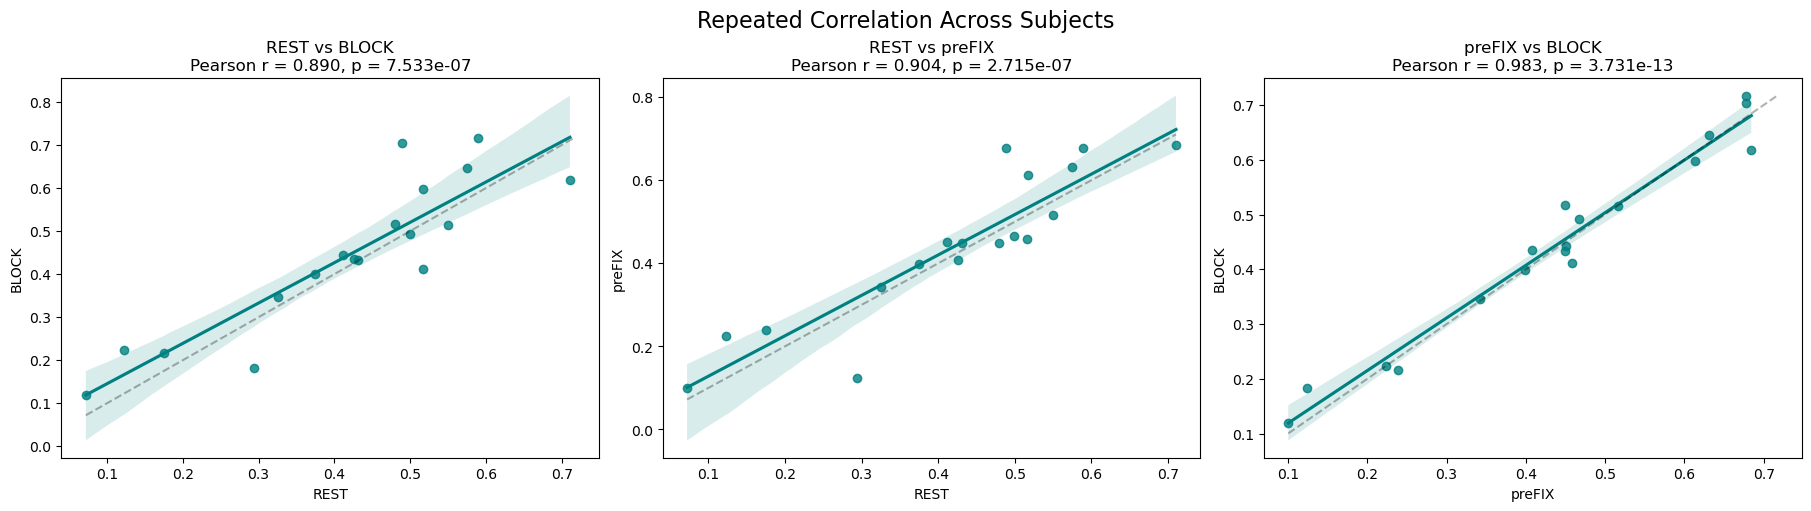

In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.formula.api as smf
from scipy.stats import pearsonr, ttest_rel

# --- Example FC strength data per subject per condition (replace with your real data)
# These arrays should each be shape (n_subjects,)
fc_rest = np.mean(rest_all, axis=(2, 3))[:, 0]     # collapse to 1 value per subject
fc_fix = np.mean(fix_all, axis=(2, 3))[:, 0]
fc_block = np.mean(block_all, axis=(2, 3))[:, 0]

# Create DataFrame
df = pd.DataFrame({
    'Subject': np.arange(len(fc_rest)),
    'REST': fc_rest,
    'preFIX': fc_fix,
    'BLOCK': fc_block
})

# --- Melt for plotting
df_melted = df.melt(id_vars='Subject', var_name='Condition', value_name='FC')

# --- Plot pairwise scatter comparisons
fig, axes = plt.subplots(1, 3, figsize=(18, 5), constrained_layout=True)

pairs = [('REST', 'BLOCK'), ('REST', 'preFIX'), ('preFIX', 'BLOCK')]
titles = ['REST vs BLOCK', 'REST vs preFIX', 'preFIX vs BLOCK']

for ax, (cond1, cond2), title in zip(axes, pairs, titles):
    x = df[cond1]
    y = df[cond2]
    r, p = pearsonr(x, y)
    sns.regplot(x=x, y=y, ax=ax, color='teal')
    ax.set_xlabel(cond1)
    ax.set_ylabel(cond2)
    ax.set_title(f'{title}\nPearson r = {r:.3f}, p = {p:.3e}')
    ax.plot([min(x.min(), y.min()), max(x.max(), y.max())],
            [min(x.min(), y.min()), max(x.max(), y.max())], 'k--', alpha=0.3)

plt.suptitle("Repeated Correlation Across Subjects", fontsize=16)
plt.show()


In [15]:
# Example: Linear regression REST ~ BLOCK
df_reg = df.copy()
model = smf.ols("REST ~ BLOCK", data=df_reg).fit()
print(model.summary())


                            OLS Regression Results                            
Dep. Variable:                   REST   R-squared:                       0.792
Model:                            OLS   Adj. R-squared:                  0.779
Method:                 Least Squares   F-statistic:                     61.04
Date:                Tue, 29 Jul 2025   Prob (F-statistic):           7.53e-07
Time:                        08:38:56   Log-Likelihood:                 21.152
No. Observations:                  18   AIC:                            -38.30
Df Residuals:                      16   BIC:                            -36.52
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      0.0437      0.052      0.845      0.4

C:\Users\Peter\anaconda3\lib\site-packages\scipy\stats\_stats_py.py:1736: UserWarning: kurtosistest only valid for n>=20 ... continuing anyway, n=18
  warnings.warn("kurtosistest only valid for n>=20 ... continuing "


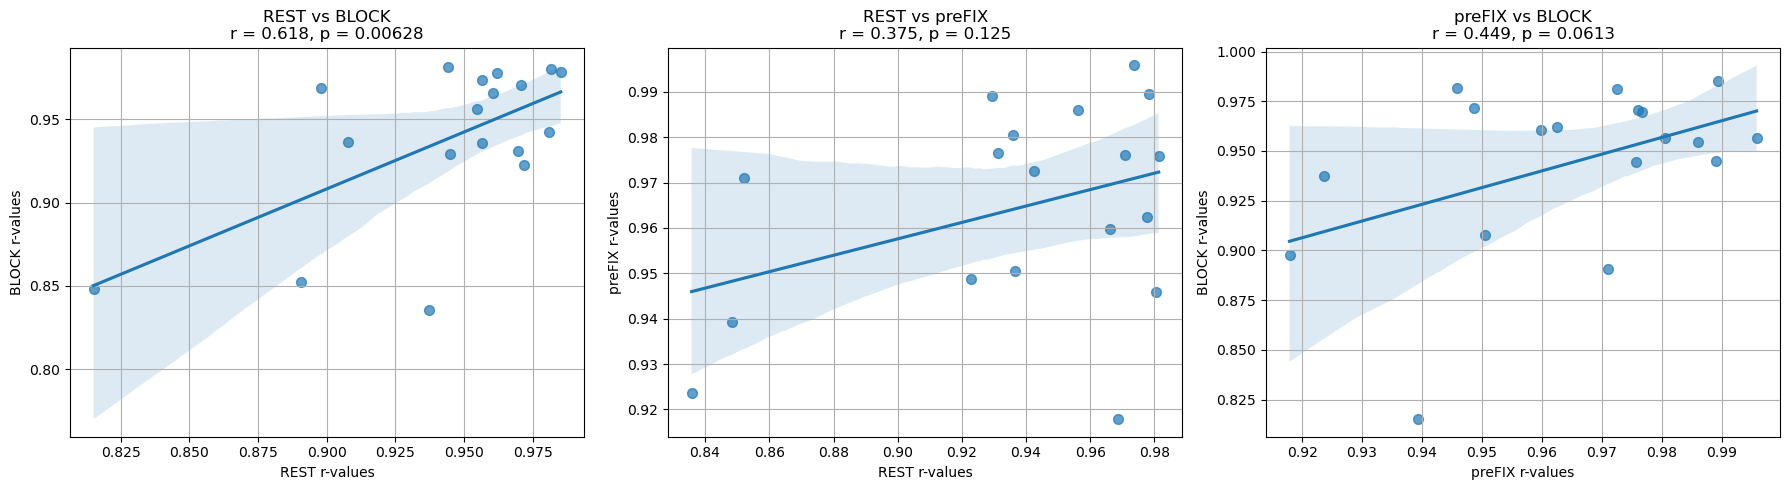

In [16]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import pearsonr
import seaborn as sns

# Your per-subject correlation arrays (example placeholders)
# Replace these with your actual arrays!
r_rest_block_all = np.array(r_rest_block_all)
r_rest_fix_all = np.array(r_rest_fix_all)
r_fix_block_all = np.array(r_fix_block_all)

pairs = [
    (r_rest_block_all, r_rest_fix_all, "REST vs BLOCK"),
    (r_rest_fix_all, r_fix_block_all, "REST vs preFIX"),
    (r_fix_block_all, r_rest_block_all, "preFIX vs BLOCK"),
]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (x, y, title) in zip(axes, pairs):
    sns.regplot(x=x, y=y, ax=ax, scatter_kws={'s':50, 'alpha':0.7})
    
    r_val, p_val = pearsonr(x, y)
    ax.set_title(f"{title}\nr = {r_val:.3f}, p = {p_val:.3g}")
    ax.set_xlabel(f"{title.split(' vs ')[0]} r-values")
    ax.set_ylabel(f"{title.split(' vs ')[1]} r-values")
    ax.grid(True)

plt.tight_layout()
plt.show()


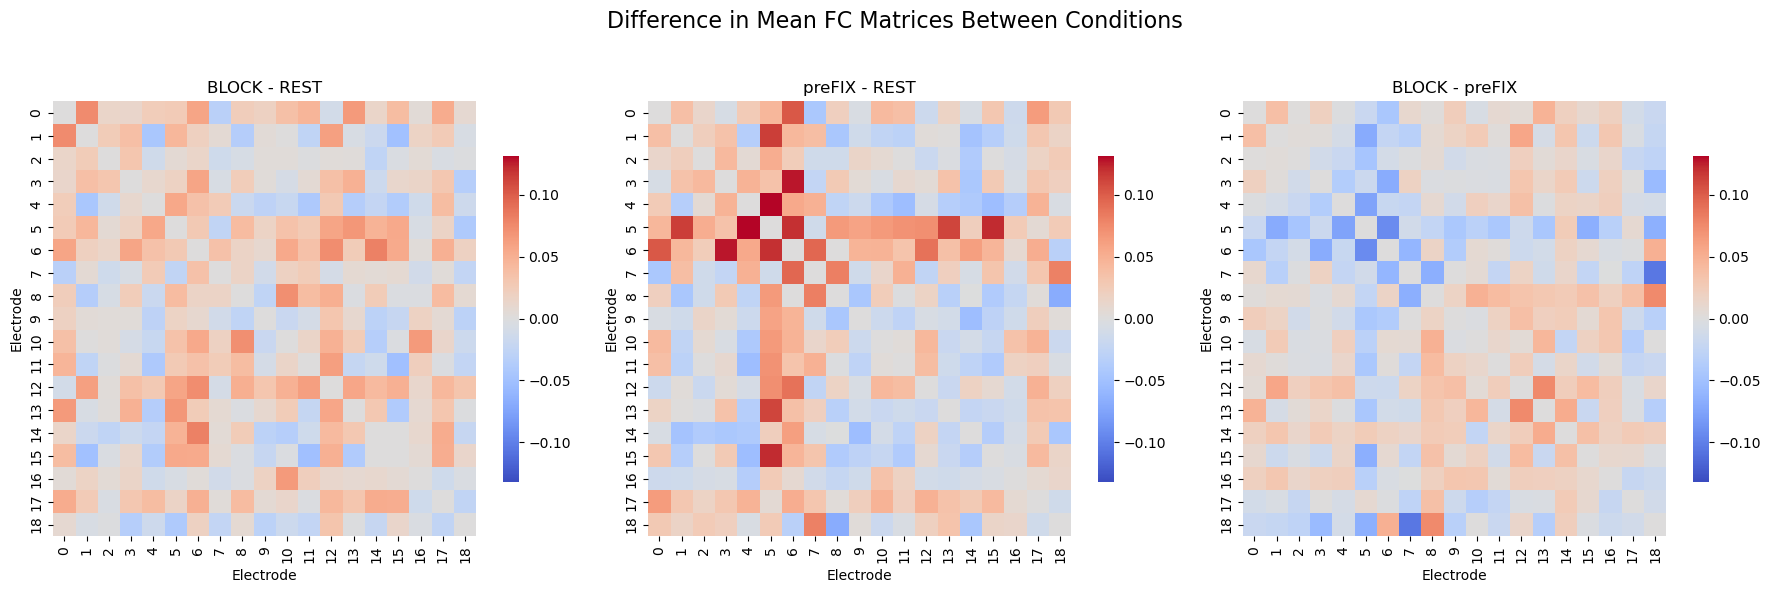

In [17]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

def compute_mean_fc(fc_array):
    # Average over subjects and blocks: shape (subjects, electrodes, electrodes, blocks)
    return np.nanmean(fc_array, axis=(0, 3))

# Compute mean FC matrices for each condition
mean_rest = compute_mean_fc(rest_all)
mean_fix = compute_mean_fc(fix_all)
mean_block = compute_mean_fc(block_all)

# Compute difference matrices
diff_block_rest = mean_block - mean_rest
diff_fix_rest = mean_fix - mean_rest
diff_block_fix = mean_block - mean_fix

# Plotting
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

vmax = np.max([np.abs(diff_block_rest).max(), np.abs(diff_fix_rest).max(), np.abs(diff_block_fix).max()])

for ax, diff_mat, title in zip(axes, 
                               [diff_block_rest, diff_fix_rest, diff_block_fix],
                               ['BLOCK - REST', 'preFIX - REST', 'BLOCK - preFIX']):
    sns.heatmap(diff_mat, ax=ax, center=0, cmap='coolwarm', vmin=-vmax, vmax=vmax,
                cbar_kws={'shrink': 0.75})
    ax.set_title(title)
    ax.set_xlabel('Electrode')
    ax.set_ylabel('Electrode')

plt.suptitle('Difference in Mean FC Matrices Between Conditions', fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


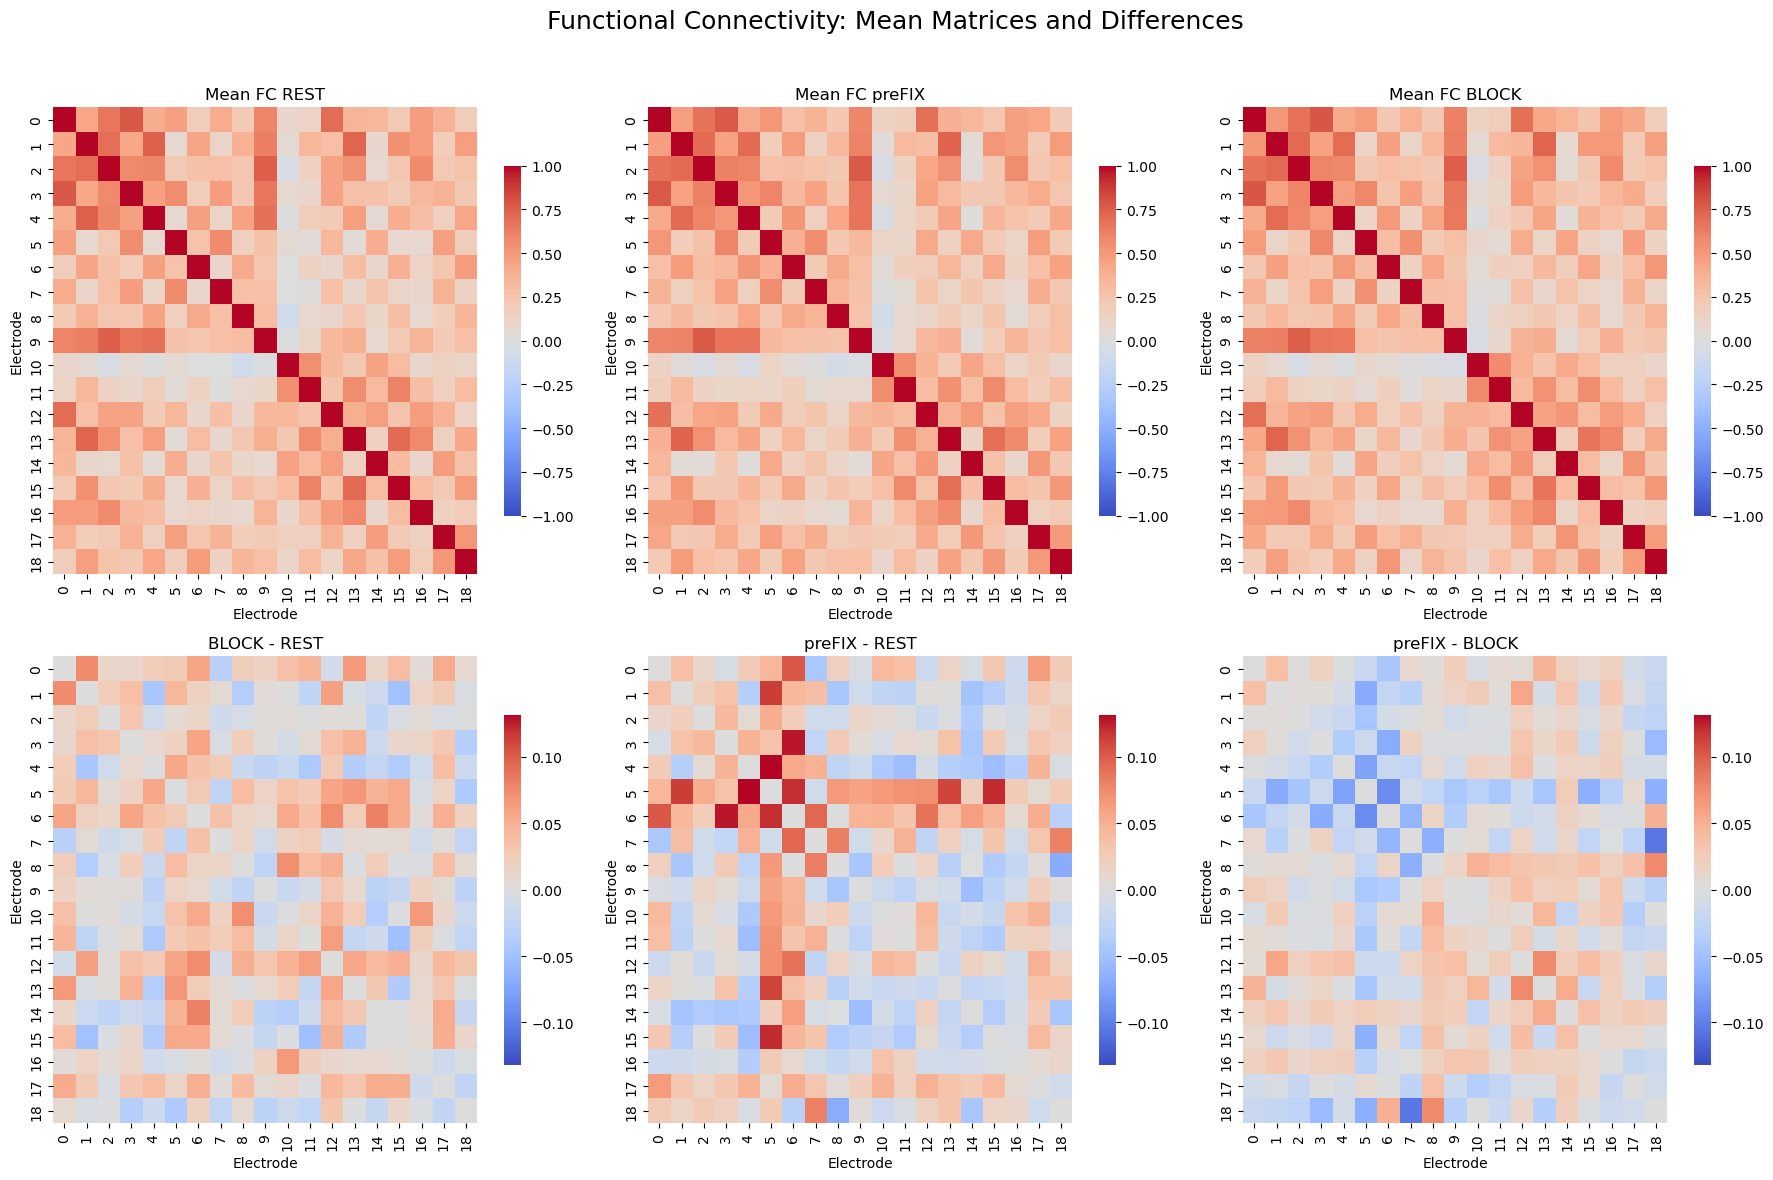

In [18]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

def compute_mean_fc(fc_array):
    # Average over subjects and blocks: shape (subjects, electrodes, electrodes, blocks)
    return np.nanmean(fc_array, axis=(0, 3))

# Compute mean FC matrices for each condition
mean_rest = compute_mean_fc(rest_all)
mean_fix = compute_mean_fc(fix_all)
mean_block = compute_mean_fc(block_all)

# Compute difference matrices
diff_block_rest = mean_block - mean_rest
diff_fix_rest = mean_fix - mean_rest
diff_fix_block = mean_fix-mean_block

# Set color scale limits
vmax_fc = np.max([np.abs(mean_rest).max(), np.abs(mean_fix).max(), np.abs(mean_block).max()])
vmax_diff = np.max([np.abs(diff_block_rest).max(), np.abs(diff_fix_rest).max(), np.abs(diff_fix_block).max()])

fig, axes = plt.subplots(2, 3, figsize=(18, 12))

# Top row: FC matrices
fc_matrices = [mean_rest, mean_fix, mean_block]
fc_titles = ['Mean FC REST', 'Mean FC preFIX', 'Mean FC BLOCK']

for ax, fc_mat, title in zip(axes[0], fc_matrices, fc_titles):
    sns.heatmap(fc_mat, ax=ax, cmap='coolwarm', vmin=-1, vmax=1, cbar=True,
                cbar_kws={'shrink': 0.75})
    ax.set_title(title)
    ax.set_xlabel('Electrode')
    ax.set_ylabel('Electrode')

# Bottom row: Difference matrices
diff_matrices = [diff_block_rest, diff_fix_rest, diff_block_fix]
diff_titles = ['BLOCK - REST', 'preFIX - REST', 'preFIX - BLOCK']

for ax, diff_mat, title in zip(axes[1], diff_matrices, diff_titles):
    sns.heatmap(diff_mat, ax=ax, center=0, cmap='coolwarm', vmin=-vmax_diff, vmax=vmax_diff,
                cbar=True, cbar_kws={'shrink': 0.75})
    ax.set_title(title)
    ax.set_xlabel('Electrode')
    ax.set_ylabel('Electrode')

plt.suptitle('Functional Connectivity: Mean Matrices and Differences', fontsize=18)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()


C:\Users\Peter\anaconda3\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\Peter\anaconda3\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\Peter\anaconda3\lib\site-packages\seaborn\_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)


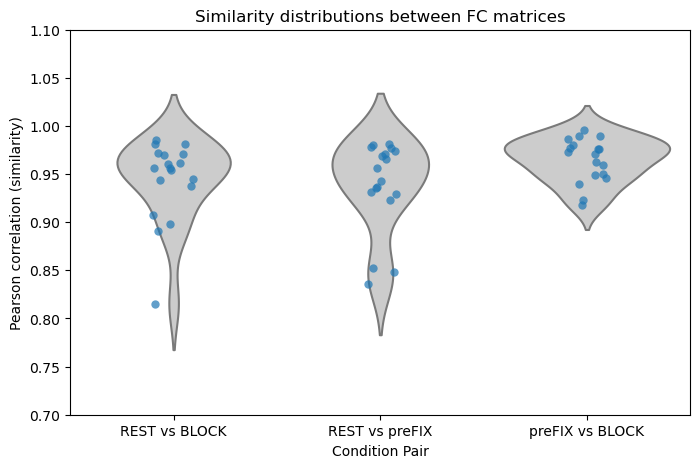

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

# Example arrays (replace these with your actual arrays)
# r_rest_block_all, r_rest_fix_all, r_fix_block_all
# Each is a list or array of length = number of subjects
# For demo, I'll create random data with similar range:


# Put data in a tidy DataFrame for seaborn
df = pd.DataFrame({
    'REST vs BLOCK': r_rest_block_all,
    'REST vs preFIX': r_rest_fix_all,
    'preFIX vs BLOCK': r_fix_block_all
})
df = df.melt(var_name='Condition Pair', value_name='Similarity (r)')

# Plot
plt.figure(figsize=(8,5))
sns.violinplot(x='Condition Pair', y='Similarity (r)', data=df, inner=None, color=".8")
sns.stripplot(x='Condition Pair', y='Similarity (r)', data=df, jitter=True, size=6, alpha=0.7)

plt.title('Similarity distributions between FC matrices')
plt.ylabel('Pearson correlation (similarity)')
plt.ylim(0.7, 1.1)
plt.show()


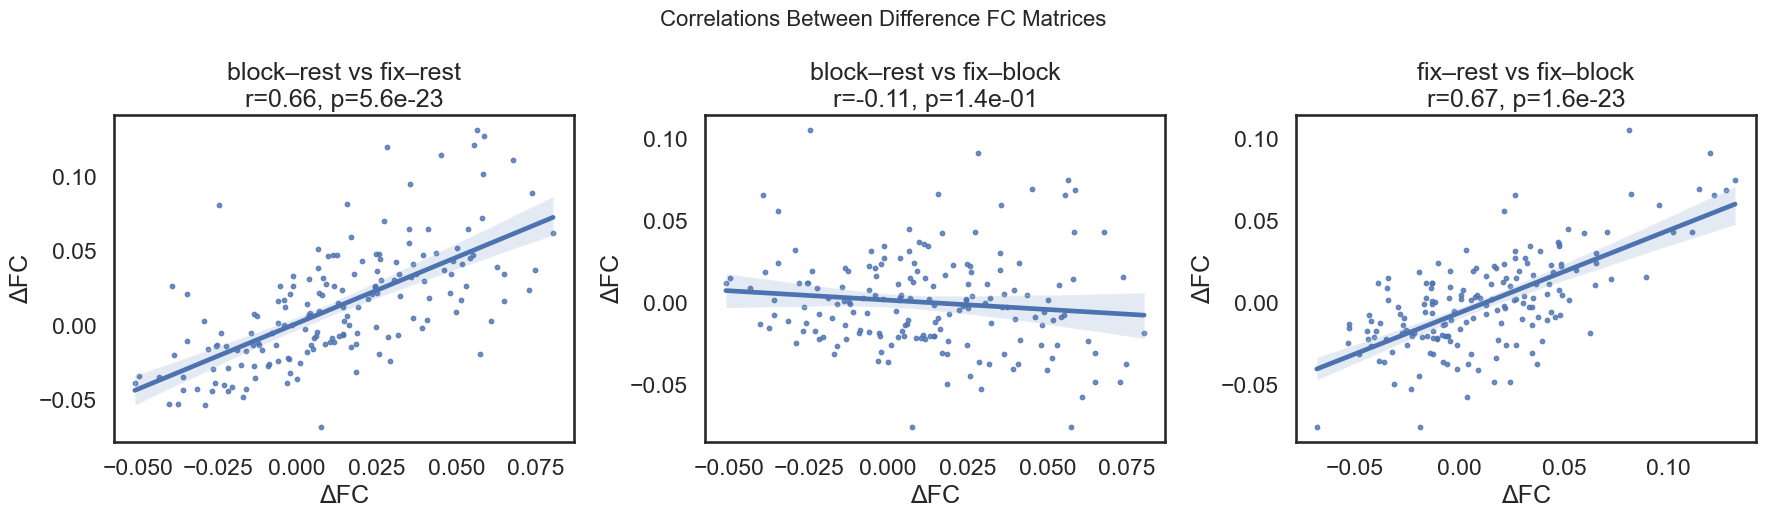

In [20]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr

# -----------------------------
# Define flatten function
def flatten_upper_tri(matrix):
    """Flatten upper triangle of symmetric matrix (excluding diagonal)."""
    triu_idx = np.triu_indices_from(matrix, k=1)
    return matrix[triu_idx]

# -----------------------------
# Difference matrices (replace with your actual data)
# Assume mean_rest, mean_fix, mean_block are already defined (electrodes x electrodes)

diff_block_rest = mean_block - mean_rest
diff_fix_rest = mean_fix - mean_rest
diff_fix_block = mean_fix - mean_block

# -----------------------------
# Flatten difference matrices
v_diff_block_rest = flatten_upper_tri(diff_block_rest)
v_diff_fix_rest = flatten_upper_tri(diff_fix_rest)
v_diff_fix_block = flatten_upper_tri(diff_fix_block)

# -----------------------------
# Compute correlations
r1, p1 = pearsonr(v_diff_block_rest, v_diff_fix_rest)
r2, p2 = pearsonr(v_diff_block_rest, v_diff_fix_block)
r3, p3 = pearsonr(v_diff_fix_rest, v_diff_fix_block)

# -----------------------------
# Prepare DataFrame for plotting
import pandas as pd
df = pd.DataFrame({
    "block - rest": v_diff_block_rest,
    "fix - rest": v_diff_fix_rest,
    "fix - block": v_diff_fix_block
})

# -----------------------------
# Plotting using seaborn regplots
sns.set(style="white", context="talk")

fig, axs = plt.subplots(1, 3, figsize=(18, 5))

# Panel A: block–rest vs fix–rest
sns.regplot(x="block - rest", y="fix - rest", data=df, ax=axs[0], scatter_kws={"s": 10})
axs[0].set_title(f"block–rest vs fix–rest\nr={r1:.2f}, p={p1:.1e}")

# Panel B: block–rest vs fix–block
sns.regplot(x="block - rest", y="fix - block", data=df, ax=axs[1], scatter_kws={"s": 10})
axs[1].set_title(f"block–rest vs fix–block\nr={r2:.2f}, p={p2:.1e}")

# Panel C: fix–rest vs fix–block
sns.regplot(x="fix - rest", y="fix - block", data=df, ax=axs[2], scatter_kws={"s": 10})
axs[2].set_title(f"fix–rest vs fix–block\nr={r3:.2f}, p={p3:.1e}")

for ax in axs:
    ax.set_xlabel("ΔFC")
    ax.set_ylabel("ΔFC")

plt.tight_layout()
plt.suptitle("Correlations Between Difference FC Matrices", y=1.05, fontsize=16)
plt.show()


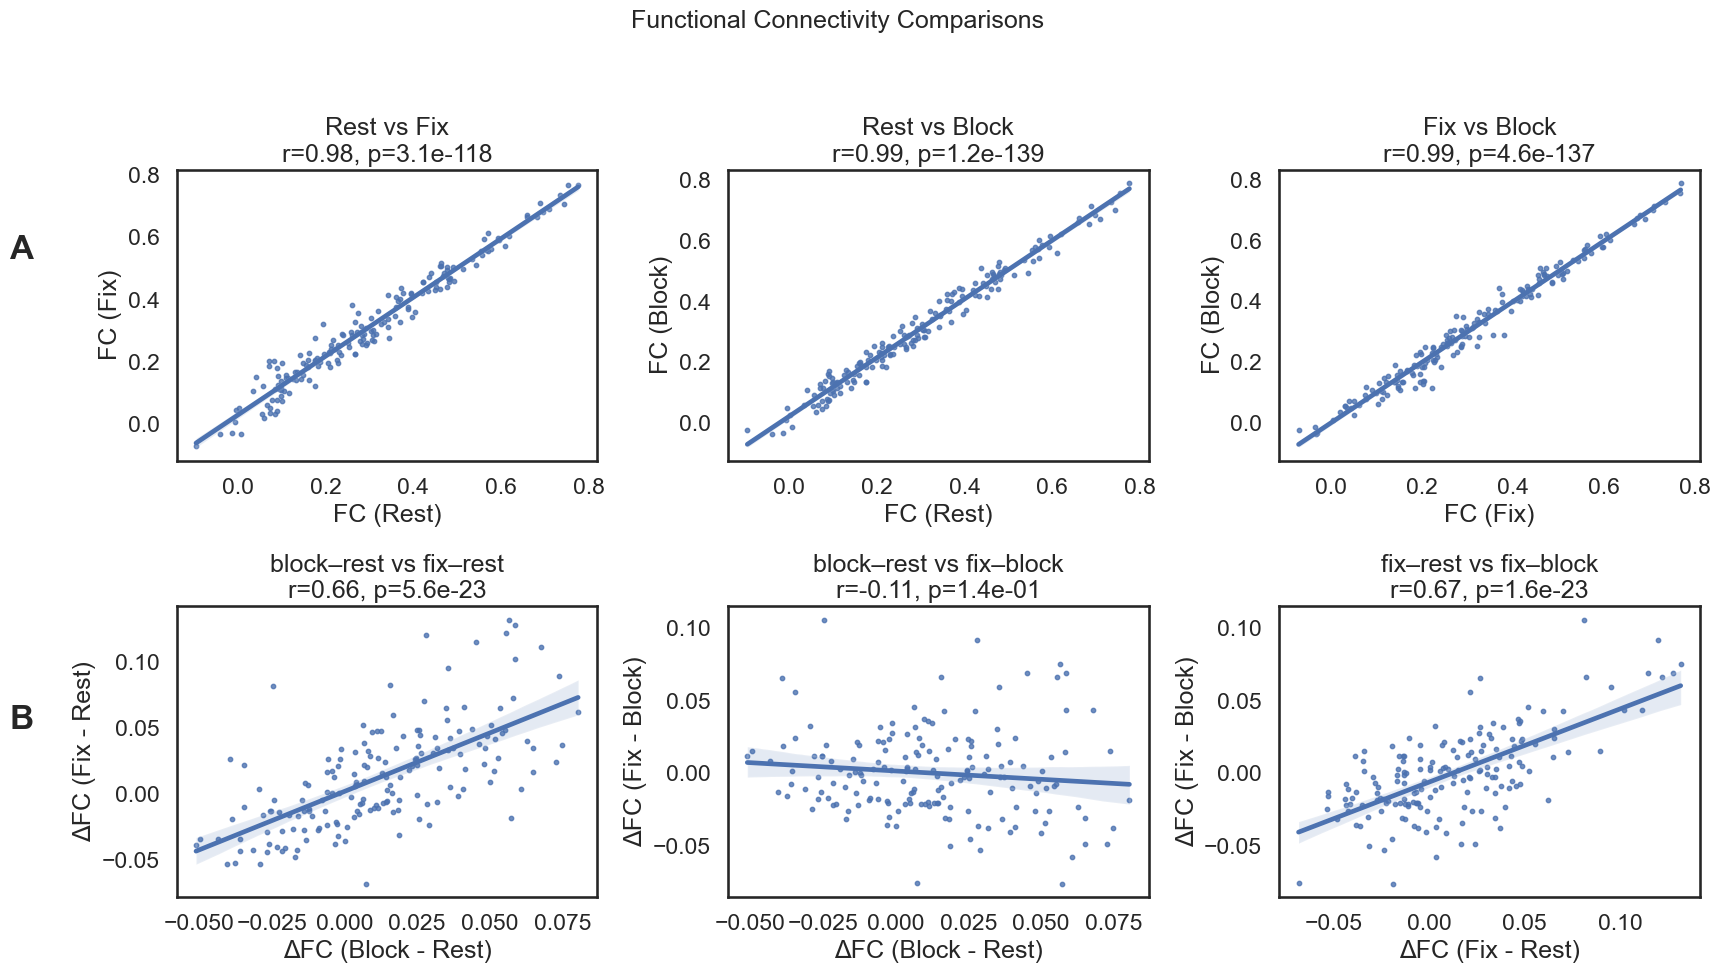

In [21]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr

sns.set(style="white", context="talk")

# -----------------------------
# Define flatten function
def flatten_upper_tri(matrix):
    """Flatten upper triangle of symmetric matrix (excluding diagonal)."""
    triu_idx = np.triu_indices_from(matrix, k=1)
    return matrix[triu_idx]

# -----------------------------
# Assume these matrices (electrodes x electrodes) are defined:
# mean_rest, mean_fix, mean_block
# Example:
# mean_rest  = np.random.rand(64, 64)
# mean_fix   = np.random.rand(64, 64)
# mean_block = np.random.rand(64, 64)

# Panel A: Full matrix comparisons (correlation of raw FC)
v_rest  = flatten_upper_tri(mean_rest)
v_fix   = flatten_upper_tri(mean_fix)
v_block = flatten_upper_tri(mean_block)

rA1, pA1 = pearsonr(v_rest, v_fix)
rA2, pA2 = pearsonr(v_rest, v_block)
rA3, pA3 = pearsonr(v_fix, v_block)

# Panel B: Difference matrix comparisons (ΔFC correlation)
diff_block_rest = mean_block - mean_rest
diff_fix_rest   = mean_fix - mean_rest
diff_fix_block  = mean_fix - mean_block

v_diff_block_rest = flatten_upper_tri(diff_block_rest)
v_diff_fix_rest   = flatten_upper_tri(diff_fix_rest)
v_diff_fix_block  = flatten_upper_tri(diff_fix_block)

rB1, pB1 = pearsonr(v_diff_block_rest, v_diff_fix_rest)
rB2, pB2 = pearsonr(v_diff_block_rest, v_diff_fix_block)
rB3, pB3 = pearsonr(v_diff_fix_rest, v_diff_fix_block)

# -----------------------------
# Plotting
fig, axes = plt.subplots(2, 3, figsize=(18, 10), sharex=False, sharey=False)
fig.suptitle("Functional Connectivity Comparisons", fontsize=18)

# Left margin labels
fig.text(0.04, 0.74, 'A', fontsize=24, fontweight='bold', va='center')
fig.text(0.04, 0.27, 'B', fontsize=24, fontweight='bold', va='center')

# ---- Panel A: Raw FC comparisons ----
sns.regplot(x=v_rest, y=v_fix, ax=axes[0, 0], scatter_kws={"s": 10})
axes[0, 0].set_title(f"Rest vs Fix\nr={rA1:.2f}, p={pA1:.1e}")
axes[0, 0].set_xlabel("FC (Rest)")
axes[0, 0].set_ylabel("FC (Fix)")

sns.regplot(x=v_rest, y=v_block, ax=axes[0, 1], scatter_kws={"s": 10})
axes[0, 1].set_title(f"Rest vs Block\nr={rA2:.2f}, p={pA2:.1e}")
axes[0, 1].set_xlabel("FC (Rest)")
axes[0, 1].set_ylabel("FC (Block)")

sns.regplot(x=v_fix, y=v_block, ax=axes[0, 2], scatter_kws={"s": 10})
axes[0, 2].set_title(f"Fix vs Block\nr={rA3:.2f}, p={pA3:.1e}")
axes[0, 2].set_xlabel("FC (Fix)")
axes[0, 2].set_ylabel("FC (Block)")

# ---- Panel B: ΔFC comparisons ----
sns.regplot(x=v_diff_block_rest, y=v_diff_fix_rest, ax=axes[1, 0], scatter_kws={"s": 10})
axes[1, 0].set_title(f"block–rest vs fix–rest\nr={rB1:.2f}, p={pB1:.1e}")
axes[1, 0].set_xlabel("ΔFC (Block - Rest)")
axes[1, 0].set_ylabel("ΔFC (Fix - Rest)")

sns.regplot(x=v_diff_block_rest, y=v_diff_fix_block, ax=axes[1, 1], scatter_kws={"s": 10})
axes[1, 1].set_title(f"block–rest vs fix–block\nr={rB2:.2f}, p={pB2:.1e}")
axes[1, 1].set_xlabel("ΔFC (Block - Rest)")
axes[1, 1].set_ylabel("ΔFC (Fix - Block)")

sns.regplot(x=v_diff_fix_rest, y=v_diff_fix_block, ax=axes[1, 2], scatter_kws={"s": 10})
axes[1, 2].set_title(f"fix–rest vs fix–block\nr={rB3:.2f}, p={pB3:.1e}")
axes[1, 2].set_xlabel("ΔFC (Fix - Rest)")
axes[1, 2].set_ylabel("ΔFC (Fix - Block)")

# Final layout
plt.tight_layout(rect=[0.06, 0, 1, 0.95])
plt.show()


Paired t-tests:
block–rest vs fix–rest  vs  block–rest vs fix–block: t=10.87, p=0.000
block–rest vs fix–block vs  fix–rest vs fix–block:  t=-8.79, p=0.000
fix–rest vs fix–block vs  block–rest vs fix–rest:  t=-2.07, p=0.054


C:\Users\Peter\anaconda3\lib\site-packages\seaborn\categorical.py:166: FutureWarning: Setting a gradient palette using color= is deprecated and will be removed in version 0.13. Set `palette='dark:.3'` for same effect.
  warnings.warn(msg, FutureWarning)
C:\Users\Peter\anaconda3\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\Peter\anaconda3\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\Peter\anaconda3\lib\site-packages\seaborn\_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `

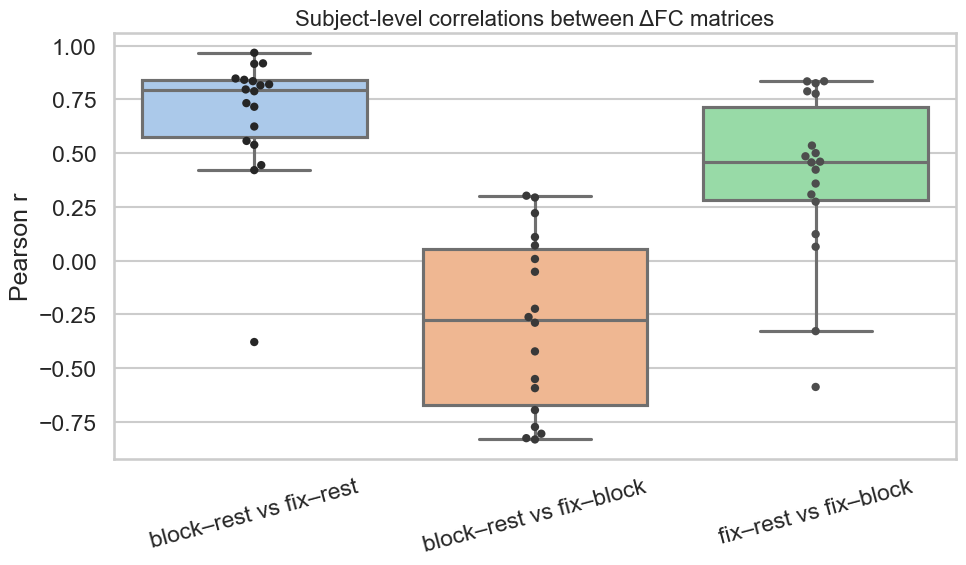

In [22]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from scipy.stats import pearsonr, ttest_rel

# -----------------------------
# Define flatten function
def flatten_upper_tri(matrix):
    """Flatten upper triangle of symmetric matrix (excluding diagonal)."""
    triu_idx = np.triu_indices_from(matrix, k=1)
    return matrix[triu_idx]

# -----------------------------
# Example input: subject-level data
# These should be lists of shape [n_subjects] where each entry is a (19, 19, 9) FC array
# subject_rest_data, subject_fix_data, subject_block_data assumed to be defined

# -----------------------------
# Initialize correlation lists
r_block_rest_vs_fix_rest = []
r_block_rest_vs_fix_block = []
r_fix_rest_vs_fix_block = []

for subj in range(len(subject_rest_data)):
    # Average across blocks for each condition
    fc_rest = np.nanmean(subject_rest_data[subj], axis=2)
    fc_fix = np.nanmean(subject_fix_data[subj], axis=2)
    fc_block = np.nanmean(subject_block_data[subj], axis=2)

    # Compute subject-level difference matrices
    d_block_rest = flatten_upper_tri(fc_block - fc_rest)
    d_fix_rest = flatten_upper_tri(fc_fix - fc_rest)
    d_fix_block = flatten_upper_tri(fc_fix - fc_block)

    # Correlate difference vectors
    r1, _ = pearsonr(d_block_rest, d_fix_rest)
    r2, _ = pearsonr(d_block_rest, d_fix_block)
    r3, _ = pearsonr(d_fix_rest, d_fix_block)

    r_block_rest_vs_fix_rest.append(r1)
    r_block_rest_vs_fix_block.append(r2)
    r_fix_rest_vs_fix_block.append(r3)

# -----------------------------
# Convert to DataFrame
df_corr = pd.DataFrame({
    "block–rest vs fix–rest": r_block_rest_vs_fix_rest,
    "block–rest vs fix–block": r_block_rest_vs_fix_block,
    "fix–rest vs fix–block": r_fix_rest_vs_fix_block
})

# -----------------------------
# Paired t-tests
t1 = ttest_rel(r_block_rest_vs_fix_rest, r_block_rest_vs_fix_block)
t2 = ttest_rel(r_block_rest_vs_fix_block, r_fix_rest_vs_fix_block)
t3 = ttest_rel(r_fix_rest_vs_fix_block, r_block_rest_vs_fix_rest)

print("Paired t-tests:")
print(f"block–rest vs fix–rest  vs  block–rest vs fix–block: t={t1.statistic:.2f}, p={t1.pvalue:.3f}")
print(f"block–rest vs fix–block vs  fix–rest vs fix–block:  t={t2.statistic:.2f}, p={t2.pvalue:.3f}")
print(f"fix–rest vs fix–block vs  block–rest vs fix–rest:  t={t3.statistic:.2f}, p={t3.pvalue:.3f}")

# -----------------------------
# Plot
sns.set(style="whitegrid", context="talk")
plt.figure(figsize=(10, 6))
sns.boxplot(data=df_corr, palette="pastel", showfliers=False)
sns.swarmplot(data=df_corr, color=".3", size=6)
plt.title("Subject-level correlations between ΔFC matrices", fontsize=16)
plt.ylabel("Pearson r")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()


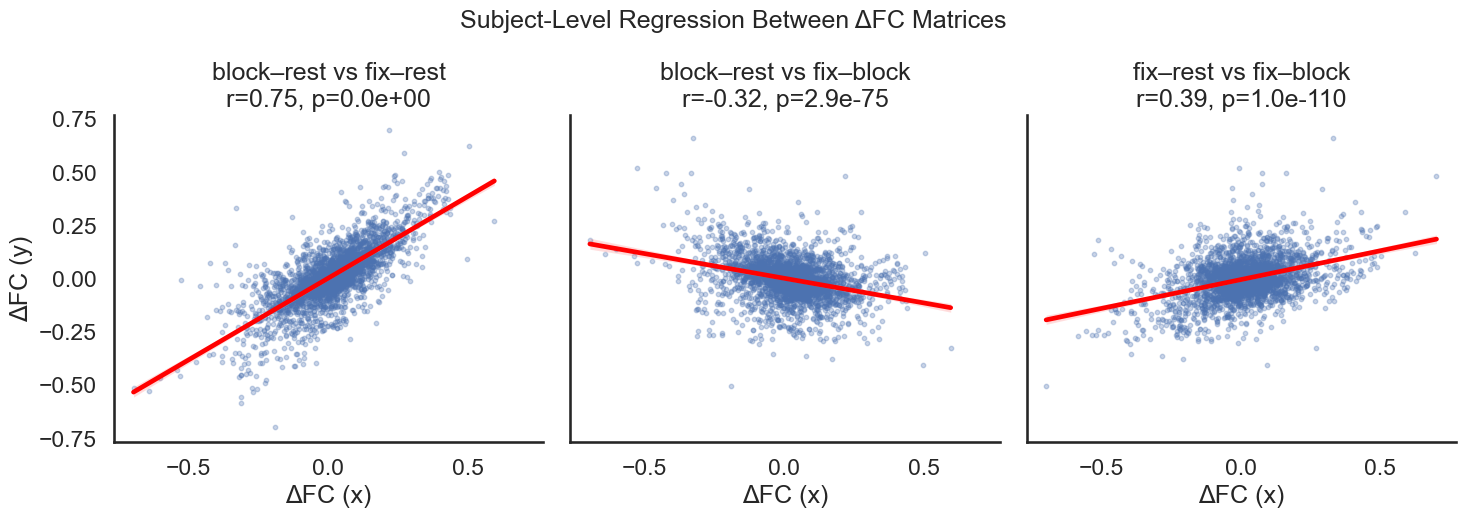

In [23]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from scipy.stats import pearsonr

# -----------------------------
# Flatten upper triangle
def flatten_upper_tri(matrix):
    triu_idx = np.triu_indices_from(matrix, k=1)
    return matrix[triu_idx]

# -----------------------------
# Assume subject_rest_data, subject_fix_data, subject_block_data are lists of shape [n_subjects]
# Each element has shape (19, 19, 9): FC matrices for each block

# -----------------------------
# Store all flattened differences
v_block_rest_all = []
v_fix_rest_all = []
v_fix_block_all = []

# Compute per-subject average FC and flatten difference matrices
for subj in range(len(subject_rest_data)):
    fc_rest = np.nanmean(subject_rest_data[subj], axis=2)
    fc_fix = np.nanmean(subject_fix_data[subj], axis=2)
    fc_block = np.nanmean(subject_block_data[subj], axis=2)

    v_block_rest = flatten_upper_tri(fc_block - fc_rest)
    v_fix_rest = flatten_upper_tri(fc_fix - fc_rest)
    v_fix_block = flatten_upper_tri(fc_fix - fc_block)

    v_block_rest_all.append(v_block_rest)
    v_fix_rest_all.append(v_fix_rest)
    v_fix_block_all.append(v_fix_block)

# Convert to arrays of shape (n_subjects, n_edges)
v_block_rest_all = np.array(v_block_rest_all)
v_fix_rest_all = np.array(v_fix_rest_all)
v_fix_block_all = np.array(v_fix_block_all)

# -----------------------------
# Create long-form DataFrame for plotting all subject-pairs
def build_regression_df(x_all, y_all, label):
    df_list = []
    for subj in range(x_all.shape[0]):
        df = pd.DataFrame({
            'x': x_all[subj],
            'y': y_all[subj],
            'subject': subj,
            'comparison': label
        })
        df_list.append(df)
    return pd.concat(df_list, ignore_index=True)

df_r1 = build_regression_df(v_block_rest_all, v_fix_rest_all, 'block–rest vs fix–rest')
df_r2 = build_regression_df(v_block_rest_all, v_fix_block_all, 'block–rest vs fix–block')
df_r3 = build_regression_df(v_fix_rest_all, v_fix_block_all, 'fix–rest vs fix–block')

df_all = pd.concat([df_r1, df_r2, df_r3], ignore_index=True)

# -----------------------------
# Plot
sns.set(style="white", context="talk")
g = sns.lmplot(
    data=df_all,
    x='x', y='y',
    col='comparison',
    col_wrap=3,
    height=5,
    scatter_kws={'s': 10, 'alpha': 0.3},
    line_kws={'color': 'red'}
)

# Compute global stats per panel
comparisons = {
    'block–rest vs fix–rest': (v_block_rest_all, v_fix_rest_all),
    'block–rest vs fix–block': (v_block_rest_all, v_fix_block_all),
    'fix–rest vs fix–block': (v_fix_rest_all, v_fix_block_all),
}

for ax, label in zip(g.axes.flat, comparisons):
    x_flat = comparisons[label][0].flatten()
    y_flat = comparisons[label][1].flatten()
    r, p = pearsonr(x_flat, y_flat)
    ax.set_title(f"{label}\nr={r:.2f}, p={p:.1e}")
    ax.set_xlabel("ΔFC (x)")
    ax.set_ylabel("ΔFC (y)")

plt.tight_layout()
plt.suptitle("Subject-Level Regression Between ΔFC Matrices", y=1.05, fontsize=18)
plt.show()


C:\Users\Peter\anaconda3\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\Peter\anaconda3\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\Peter\anaconda3\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


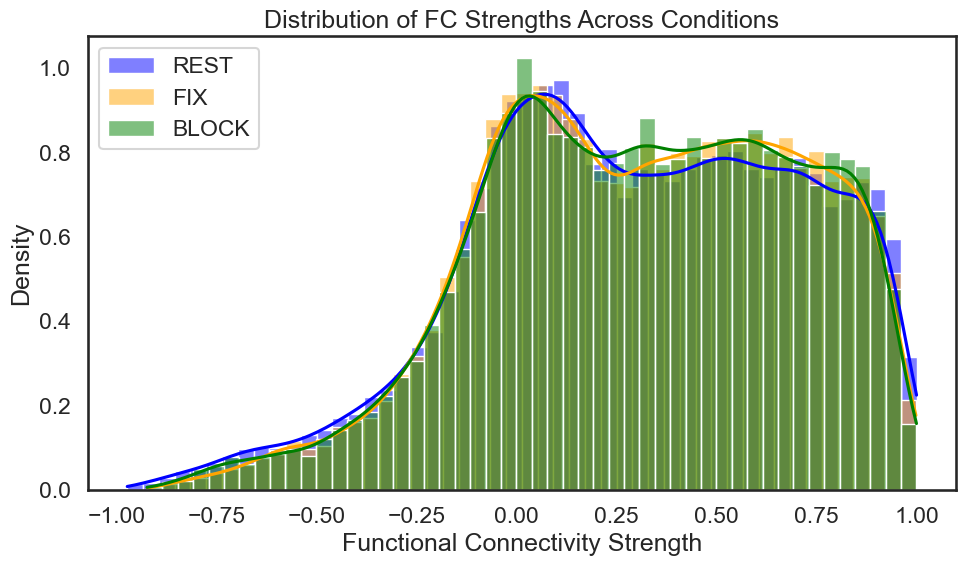

Mann–Whitney U tests (two-sided):
REST vs FIX: MannwhitneyuResult(statistic=379007701.0, pvalue=0.012665742517244383)
REST vs BLOCK: MannwhitneyuResult(statistic=378449952.0, pvalue=0.005281553428568078)
FIX vs BLOCK: MannwhitneyuResult(statistic=383144894.0, pvalue=0.7679041310289292)


In [24]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import mannwhitneyu

def flatten_upper_tri(matrix):
    """Flatten the upper triangle of a square matrix (excluding diagonal)."""
    return matrix[np.triu_indices_from(matrix, k=1)]

# Replace these with your actual lists of arrays
# Each entry in the list is an array of shape (19, 19, 9)
subject_rest_data = [rest_all[i] for i in range(rest_all.shape[0])]
subject_fix_data = [fix_all[i] for i in range(fix_all.shape[0])]
subject_block_data = [block_all[i] for i in range(block_all.shape[0])]

# Collect FC values
rest_fc_vals = []
fix_fc_vals = []
block_fc_vals = []

# Aggregate all upper triangle FC values across subjects and blocks
for i in range(len(subject_rest_data)):
    for b in range(subject_rest_data[i].shape[-1]):
        rest_fc_vals.extend(flatten_upper_tri(subject_rest_data[i][:, :, b]))
        fix_fc_vals.extend(flatten_upper_tri(subject_fix_data[i][:, :, b]))
        block_fc_vals.extend(flatten_upper_tri(subject_block_data[i][:, :, b]))

# Convert to numpy arrays
rest_fc_vals = np.array(rest_fc_vals)
fix_fc_vals = np.array(fix_fc_vals)
block_fc_vals = np.array(block_fc_vals)

# Plot histograms
plt.figure(figsize=(10, 6))
sns.histplot(rest_fc_vals, color='blue', label='REST', kde=True, stat='density', bins=50)
sns.histplot(fix_fc_vals, color='orange', label='FIX', kde=True, stat='density', bins=50)
sns.histplot(block_fc_vals, color='green', label='BLOCK', kde=True, stat='density', bins=50)
plt.xlabel("Functional Connectivity Strength")
plt.ylabel("Density")
plt.title("Distribution of FC Strengths Across Conditions")
plt.legend()
plt.tight_layout()
plt.show()

# Mann–Whitney U tests
print("Mann–Whitney U tests (two-sided):")
print("REST vs FIX:", mannwhitneyu(rest_fc_vals, fix_fc_vals, alternative='two-sided'))
print("REST vs BLOCK:", mannwhitneyu(rest_fc_vals, block_fc_vals, alternative='two-sided'))
print("FIX vs BLOCK:", mannwhitneyu(fix_fc_vals, block_fc_vals, alternative='two-sided'))


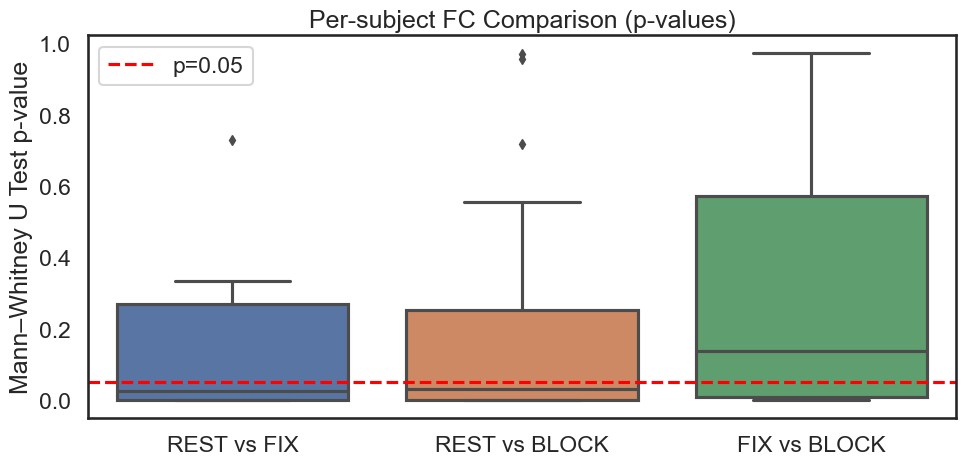

Subjects with p < 0.05:
REST vs FIX: 10 / 18
REST vs BLOCK: 10 / 18
FIX vs BLOCK: 6 / 18


In [25]:
import numpy as np
from scipy.stats import mannwhitneyu
import matplotlib.pyplot as plt
import seaborn as sns

def flatten_upper_tri(matrix):
    return matrix[np.triu_indices_from(matrix, k=1)]

# Prepare lists to store per-subject p-values
pvals_rest_fix = []
pvals_rest_block = []
pvals_fix_block = []

stat_rest_fix = []
stat_rest_block = []
stat_fix_block = []

n_subjects = len(subject_rest_data)

for i in range(n_subjects):
    rest_vals = []
    fix_vals = []
    block_vals = []

    for b in range(subject_rest_data[i].shape[-1]):
        rest_vals.extend(flatten_upper_tri(subject_rest_data[i][:, :, b]))
        fix_vals.extend(flatten_upper_tri(subject_fix_data[i][:, :, b]))
        block_vals.extend(flatten_upper_tri(subject_block_data[i][:, :, b]))

    # Mann–Whitney U tests (within subject)
    stat, p = mannwhitneyu(rest_vals, fix_vals, alternative='two-sided')
    stat_rest_fix.append(stat)
    pvals_rest_fix.append(p)

    stat, p = mannwhitneyu(rest_vals, block_vals, alternative='two-sided')
    stat_rest_block.append(stat)
    pvals_rest_block.append(p)

    stat, p = mannwhitneyu(fix_vals, block_vals, alternative='two-sided')
    stat_fix_block.append(stat)
    pvals_fix_block.append(p)

# Convert to arrays
pvals_rest_fix = np.array(pvals_rest_fix)
pvals_rest_block = np.array(pvals_rest_block)
pvals_fix_block = np.array(pvals_fix_block)

# --- Visualize p-values ---
plt.figure(figsize=(10, 5))
sns.boxplot(data=[pvals_rest_fix, pvals_rest_block, pvals_fix_block])
plt.xticks([0, 1, 2], ['REST vs FIX', 'REST vs BLOCK', 'FIX vs BLOCK'])
plt.ylabel("Mann–Whitney U Test p-value")
plt.title("Per-subject FC Comparison (p-values)")
plt.axhline(0.05, color='red', linestyle='--', label='p=0.05')
plt.legend()
plt.tight_layout()
plt.show()

# Print how many subjects showed significant effects
print("Subjects with p < 0.05:")
print("REST vs FIX:", np.sum(pvals_rest_fix < 0.05), "/", n_subjects)
print("REST vs BLOCK:", np.sum(pvals_rest_block < 0.05), "/", n_subjects)
print("FIX vs BLOCK:", np.sum(pvals_fix_block < 0.05), "/", n_subjects)


Group-level Mann–Whitney U test results:
REST vs FIX   : stat=379007701.000, p=1.267e-02
REST vs BLOCK : stat=378449952.000, p=5.282e-03
FIX vs BLOCK  : stat=383144894.000, p=7.679e-01


C:\Users\Peter\anaconda3\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\Peter\anaconda3\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\Peter\anaconda3\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


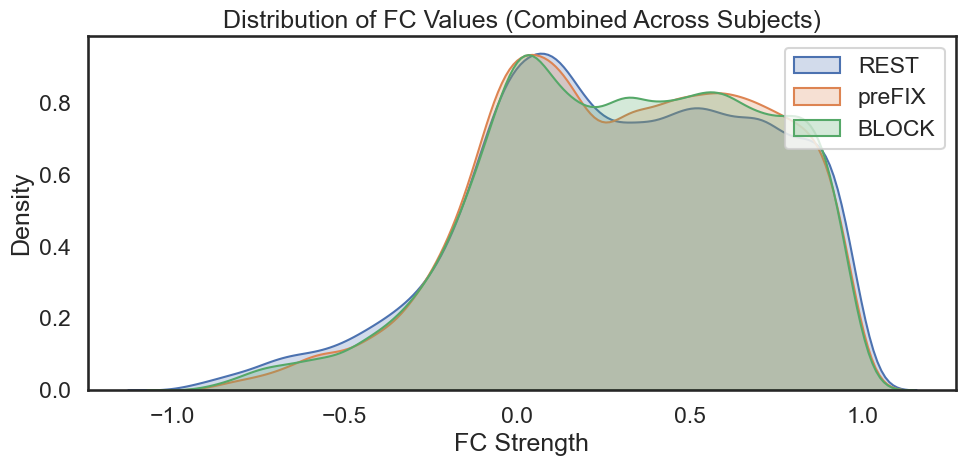

In [26]:
import numpy as np
from scipy.stats import mannwhitneyu
import matplotlib.pyplot as plt
import seaborn as sns

def flatten_upper_tri(matrix):
    return matrix[np.triu_indices_from(matrix, k=1)]

# Combine all upper triangle FC values across all subjects and blocks
rest_vals_all = []
fix_vals_all = []
block_vals_all = []

n_subjects = len(subject_rest_data)

for subj in range(n_subjects):
    for b in range(subject_rest_data[subj].shape[-1]):
        rest_vals_all.extend(flatten_upper_tri(subject_rest_data[subj][:, :, b]))
        fix_vals_all.extend(flatten_upper_tri(subject_fix_data[subj][:, :, b]))
        block_vals_all.extend(flatten_upper_tri(subject_block_data[subj][:, :, b]))

# Convert to numpy arrays
rest_vals_all = np.array(rest_vals_all)
fix_vals_all = np.array(fix_vals_all)
block_vals_all = np.array(block_vals_all)

# Mann–Whitney U tests
stat_rest_fix, p_rest_fix = mannwhitneyu(rest_vals_all, fix_vals_all, alternative='two-sided')
stat_rest_block, p_rest_block = mannwhitneyu(rest_vals_all, block_vals_all, alternative='two-sided')
stat_fix_block, p_fix_block = mannwhitneyu(fix_vals_all, block_vals_all, alternative='two-sided')

# Print results
print("Group-level Mann–Whitney U test results:")
print(f"REST vs FIX   : stat={stat_rest_fix:.3f}, p={p_rest_fix:.3e}")
print(f"REST vs BLOCK : stat={stat_rest_block:.3f}, p={p_rest_block:.3e}")
print(f"FIX vs BLOCK  : stat={stat_fix_block:.3f}, p={p_fix_block:.3e}")

# Optional: visualize distributions
plt.figure(figsize=(10, 5))
sns.kdeplot(rest_vals_all, label="REST", fill=True, linewidth=1.5)
sns.kdeplot(fix_vals_all, label="preFIX", fill=True, linewidth=1.5)
sns.kdeplot(block_vals_all, label="BLOCK", fill=True, linewidth=1.5)
plt.title("Distribution of FC Values (Combined Across Subjects)")
plt.xlabel("FC Strength")
plt.ylabel("Density")
plt.legend()
plt.tight_layout()
plt.show()


In [27]:
from scipy.stats import mannwhitneyu

# Collect all difference values across subjects and blocks
diff_block_rest = []
diff_fix_rest = []
diff_fix_block = []

for subj in range(len(subject_rest_data)):
    for b in range(subject_rest_data[subj].shape[-1]):
        rest_fc = subject_rest_data[subj][:, :, b]
        fix_fc = subject_fix_data[subj][:, :, b]
        block_fc = subject_block_data[subj][:, :, b]
        
        diff_block_rest.append(flatten_upper_tri(block_fc - rest_fc))
        diff_fix_rest.append(flatten_upper_tri(fix_fc - rest_fc))
        diff_fix_block.append(flatten_upper_tri(fix_fc - block_fc))

# Flatten across subjects and blocks
diff_block_rest = np.concatenate(diff_block_rest)
diff_fix_rest = np.concatenate(diff_fix_rest)
diff_fix_block = np.concatenate(diff_fix_block)

# Perform Mann–Whitney U tests
stat1, p1 = mannwhitneyu(diff_block_rest, diff_fix_rest, alternative='two-sided')
stat2, p2 = mannwhitneyu(diff_block_rest, diff_fix_block, alternative='two-sided')
stat3, p3 = mannwhitneyu(diff_fix_rest, diff_fix_block, alternative='two-sided')

print("Mann–Whitney tests on FC difference matrices (combined across subjects):")
print(f"BLOCK−REST vs FIX−REST:  stat={stat1:.3f}, p={p1:.3e}")
print(f"BLOCK−REST vs FIX−BLOCK: stat={stat2:.3f}, p={p2:.3e}")
print(f"FIX−REST vs FIX−BLOCK:   stat={stat3:.3f}, p={p3:.3e}")


Mann–Whitney tests on FC difference matrices (combined across subjects):
BLOCK−REST vs FIX−REST:  stat=387320567.000, p=5.445e-02
BLOCK−REST vs FIX−BLOCK: stat=398580969.000, p=2.670e-15
FIX−REST vs FIX−BLOCK:   stat=393465113.000, p=2.131e-07


C:\Users\Peter\anaconda3\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\Peter\anaconda3\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\Peter\anaconda3\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


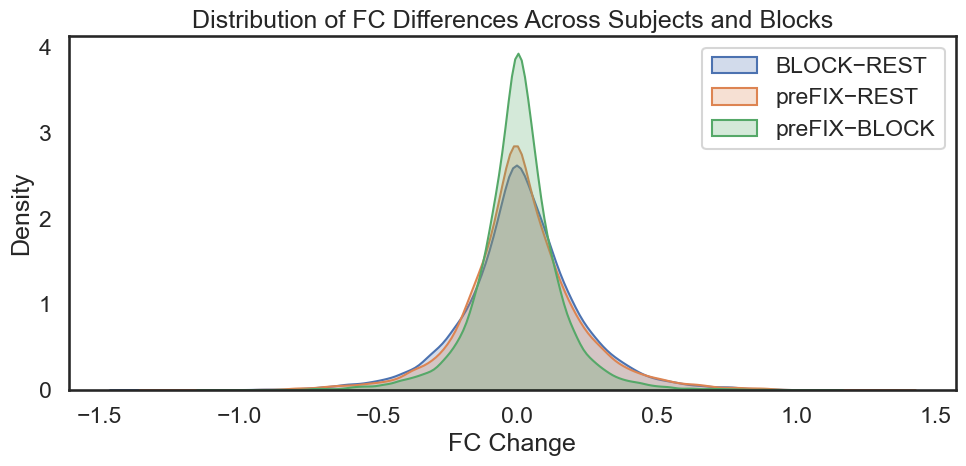

In [28]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 5))
sns.kdeplot(diff_block_rest, label="BLOCK−REST", fill=True)
sns.kdeplot(diff_fix_rest, label="preFIX−REST", fill=True)
sns.kdeplot(diff_fix_block, label="preFIX−BLOCK", fill=True)
plt.xlabel("FC Change")
plt.ylabel("Density")
plt.title("Distribution of FC Differences Across Subjects and Blocks")
plt.legend()
plt.tight_layout()
plt.show()


In [29]:
from scipy.stats import wilcoxon
import numpy as np

# Store per-subject distributions (means of difference values)
mean_diff_block_rest = []
mean_diff_fix_rest = []
mean_diff_fix_block = []

for subj in range(len(subject_rest_data)):
    subj_diff_block_rest = []
    subj_diff_fix_rest = []
    subj_diff_fix_block = []
    
    for b in range(subject_rest_data[subj].shape[-1]):
        rest_fc = subject_rest_data[subj][:, :, b]
        fix_fc = subject_fix_data[subj][:, :, b]
        block_fc = subject_block_data[subj][:, :, b]
        
        # Compute difference matrices
        d_block_rest = flatten_upper_tri(block_fc - rest_fc)
        d_fix_rest = flatten_upper_tri(fix_fc - rest_fc)
        d_fix_block = flatten_upper_tri(fix_fc - block_fc)

        subj_diff_block_rest.append(np.nanmean(d_block_rest))
        subj_diff_fix_rest.append(np.nanmean(d_fix_rest))
        subj_diff_fix_block.append(np.nanmean(d_fix_block))
    
    # Average across blocks to get a single value per subject
    mean_diff_block_rest.append(np.mean(subj_diff_block_rest))
    mean_diff_fix_rest.append(np.mean(subj_diff_fix_rest))
    mean_diff_fix_block.append(np.mean(subj_diff_fix_block))

# Paired tests across subjects
w1 = wilcoxon(mean_diff_block_rest, mean_diff_fix_rest)
w2 = wilcoxon(mean_diff_block_rest, mean_diff_fix_block)
w3 = wilcoxon(mean_diff_fix_rest, mean_diff_fix_block)

print("Wilcoxon signed-rank tests (paired, per subject):")
print(f"BLOCK−REST vs FIX−REST:  statistic={w1.statistic:.3f}, p={w1.pvalue:.3e}")
print(f"BLOCK−REST vs FIX−BLOCK: statistic={w2.statistic:.3f}, p={w2.pvalue:.3e}")
print(f"FIX−REST vs FIX−BLOCK:   statistic={w3.statistic:.3f}, p={w3.pvalue:.3e}")


Wilcoxon signed-rank tests (paired, per subject):
BLOCK−REST vs FIX−REST:  statistic=77.000, p=7.337e-01
BLOCK−REST vs FIX−BLOCK: statistic=79.000, p=7.987e-01
FIX−REST vs FIX−BLOCK:   statistic=69.000, p=4.951e-01


Wilcoxon tests by subject:
Rest vs Block: WilcoxonResult(statistic=69.0, pvalue=0.49507904052734375)
Rest vs Fix: WilcoxonResult(statistic=71.0, pvalue=0.550872802734375)
Fix vs Block: WilcoxonResult(statistic=77.0, pvalue=0.7337265014648438)

Correlations between difference FC vectors:
block-rest vs fix-rest: r=0.663, p=5.592e-23
block-rest vs fix-block: r=-0.114, p=1.391e-01
fix-rest vs fix-block: r=0.669, p=1.561e-23


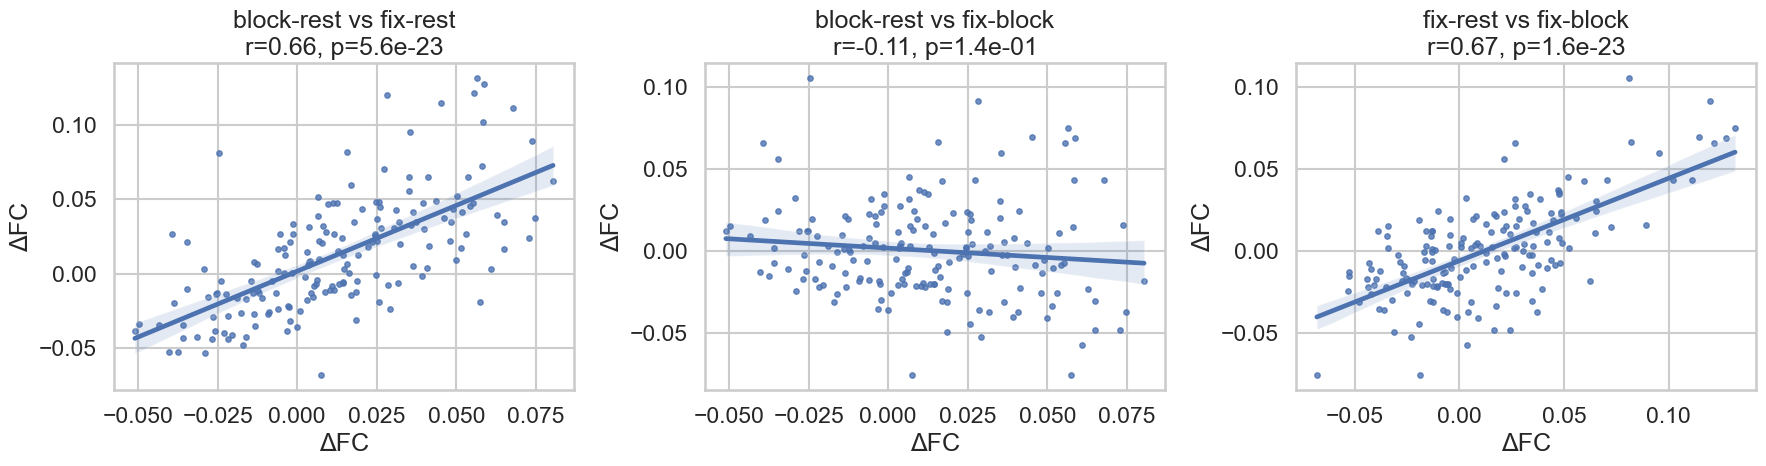

C:\Users\Peter\anaconda3\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\Peter\anaconda3\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\Peter\anaconda3\lib\site-packages\seaborn\_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)


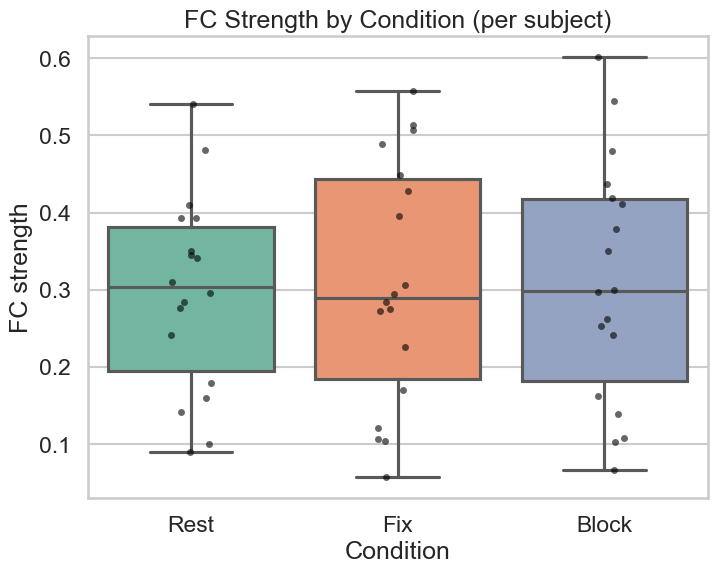

In [30]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import wilcoxon, pearsonr

# ---------- Helper function ----------
def flatten_upper_tri(matrix):
    """Flatten upper triangle of a symmetric matrix excluding diagonal."""
    triu_idx = np.triu_indices_from(matrix, k=1)
    return matrix[triu_idx]

# ---------- Compute mean FC strength per subject ----------
def mean_fc_strength(fc_array):
    # fc_array shape: (subjects, electrodes, electrodes, blocks)
    n_subjects = fc_array.shape[0]
    mean_strengths = []
    for subj in range(n_subjects):
        # Average across blocks
        mean_fc = np.nanmean(fc_array[subj], axis=2)
        # Flatten upper triangle
        vals = flatten_upper_tri(mean_fc)
        # Mean FC strength per subject
        mean_strengths.append(np.nanmean(vals))
    return np.array(mean_strengths)

# Replace these with your actual data arrays
# rest_all, fix_all, block_all shapes: (18, 19, 19, 9)
# e.g. rest_all = np.load('rest_all.npy') 

fc_rest_strength = mean_fc_strength(rest_all)
fc_fix_strength = mean_fc_strength(fix_all)
fc_block_strength = mean_fc_strength(block_all)

print("Wilcoxon tests by subject:")
print("Rest vs Block:", wilcoxon(fc_rest_strength, fc_block_strength))
print("Rest vs Fix:", wilcoxon(fc_rest_strength, fc_fix_strength))
print("Fix vs Block:", wilcoxon(fc_fix_strength, fc_block_strength))

# ---------- Compute mean FC matrices across subjects and blocks ----------
mean_rest = np.nanmean(np.nanmean(rest_all, axis=0), axis=2)  # shape (19,19)
mean_fix = np.nanmean(np.nanmean(fix_all, axis=0), axis=2)
mean_block = np.nanmean(np.nanmean(block_all, axis=0), axis=2)

# ---------- Difference matrices ----------
diff_block_rest = mean_block - mean_rest
diff_fix_rest = mean_fix - mean_rest
diff_fix_block = mean_fix - mean_block

v_diff_block_rest = flatten_upper_tri(diff_block_rest)
v_diff_fix_rest = flatten_upper_tri(diff_fix_rest)
v_diff_fix_block = flatten_upper_tri(diff_fix_block)

# ---------- Correlations between difference vectors ----------
r1, p1 = pearsonr(v_diff_block_rest, v_diff_fix_rest)
r2, p2 = pearsonr(v_diff_block_rest, v_diff_fix_block)
r3, p3 = pearsonr(v_diff_fix_rest, v_diff_fix_block)

print("\nCorrelations between difference FC vectors:")
print(f"block-rest vs fix-rest: r={r1:.3f}, p={p1:.3e}")
print(f"block-rest vs fix-block: r={r2:.3f}, p={p2:.3e}")
print(f"fix-rest vs fix-block: r={r3:.3f}, p={p3:.3e}")

# ---------- Prepare DataFrame for plotting ----------
df_diff = pd.DataFrame({
    "block-rest": v_diff_block_rest,
    "fix-rest": v_diff_fix_rest,
    "fix-block": v_diff_fix_block
})

# ---------- Plot regression scatterplots ----------
sns.set(style="whitegrid", context="talk")
fig, axs = plt.subplots(1, 3, figsize=(18,5))

sns.regplot(x="block-rest", y="fix-rest", data=df_diff, ax=axs[0], scatter_kws={"s":15})
axs[0].set_title(f"block-rest vs fix-rest\nr={r1:.2f}, p={p1:.1e}")

sns.regplot(x="block-rest", y="fix-block", data=df_diff, ax=axs[1], scatter_kws={"s":15})
axs[1].set_title(f"block-rest vs fix-block\nr={r2:.2f}, p={p2:.1e}")

sns.regplot(x="fix-rest", y="fix-block", data=df_diff, ax=axs[2], scatter_kws={"s":15})
axs[2].set_title(f"fix-rest vs fix-block\nr={r3:.2f}, p={p3:.1e}")

for ax in axs:
    ax.set_xlabel("ΔFC")
    ax.set_ylabel("ΔFC")

plt.tight_layout()
plt.show()

# ---------- Plot FC strength distributions per subject ----------
df_strength = pd.DataFrame({
    "FC strength": np.concatenate([fc_rest_strength, fc_fix_strength, fc_block_strength]),
    "Condition": ["Rest"]*len(fc_rest_strength) + ["Fix"]*len(fc_fix_strength) + ["Block"]*len(fc_block_strength)
})

plt.figure(figsize=(8,6))
sns.boxplot(x="Condition", y="FC strength", data=df_strength, palette="Set2")
sns.stripplot(x="Condition", y="FC strength", data=df_strength, color="black", alpha=0.6, jitter=True)
plt.title("FC Strength by Condition (per subject)")
plt.show()


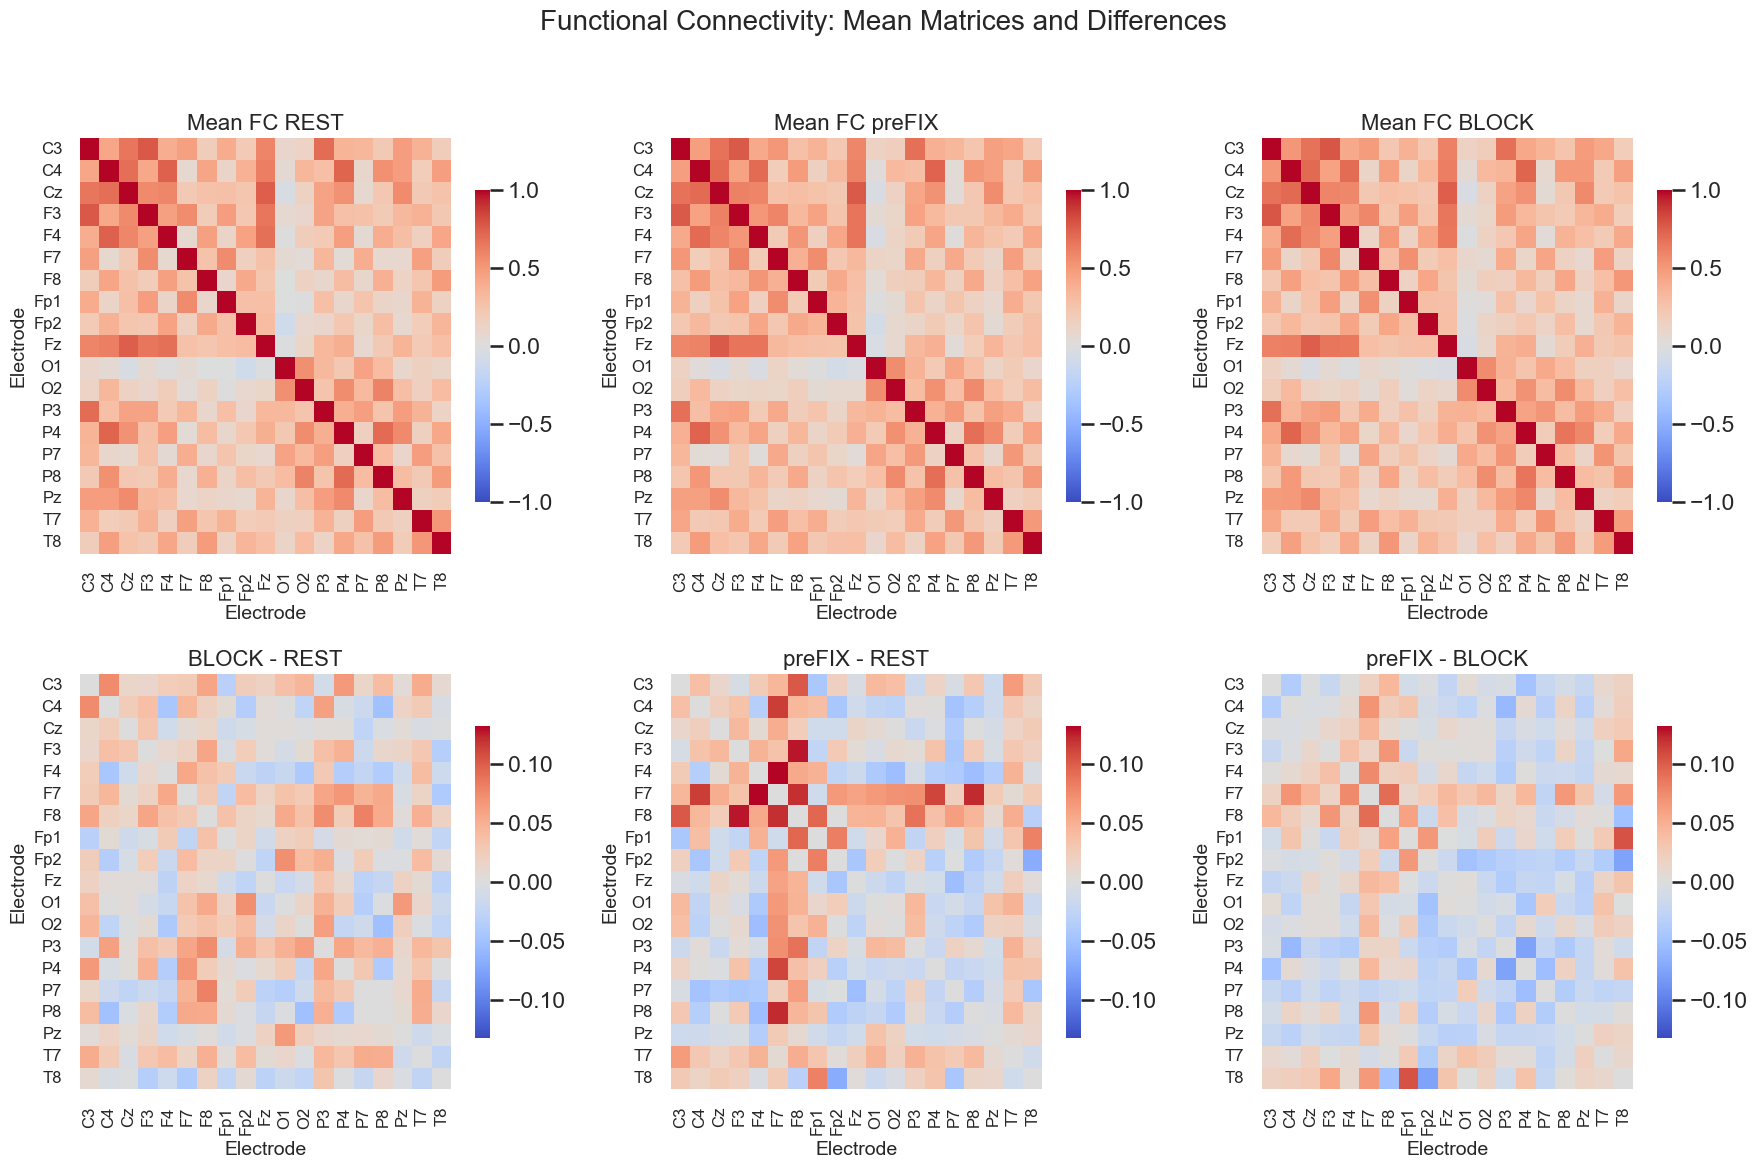

In [33]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Define common electrodes
common_electrodes_base = [
    'C3', 'C4', 'Cz', 'F3', 'F4', 'F7', 'F8', 'Fp1', 'Fp2', 
    'Fz', 'O1', 'O2', 'P3', 'P4', 'P7', 'P8', 'Pz', 'T7', 'T8'
]

def compute_mean_fc(fc_array):
    # Average over subjects and blocks: shape (subjects, electrodes, electrodes, blocks)
    return np.nanmean(fc_array, axis=(0, 3))

# Compute mean FC matrices for each condition
mean_rest = compute_mean_fc(rest_all)
mean_fix = compute_mean_fc(fix_all)
mean_block = compute_mean_fc(block_all)

# Compute difference matrices
diff_block_rest = mean_block - mean_rest
diff_fix_rest = mean_fix - mean_rest
diff_fix_block = mean_fix - mean_block

# Set color scale limits
vmax_fc = np.max([np.abs(mean_rest).max(), np.abs(mean_fix).max(), np.abs(mean_block).max()])
vmax_diff = np.max([np.abs(diff_block_rest).max(), np.abs(diff_fix_rest).max(), np.abs(diff_fix_block).max()])

fig, axes = plt.subplots(2, 3, figsize=(18, 12))

# Top row: FC matrices
fc_matrices = [mean_rest, mean_fix, mean_block]
fc_titles = ['Mean FC REST', 'Mean FC preFIX', 'Mean FC BLOCK']

for ax, fc_mat, title in zip(axes[0], fc_matrices, fc_titles):
    sns.heatmap(fc_mat, ax=ax, cmap='coolwarm', vmin=-1, vmax=1, cbar=True,
                xticklabels=valid_electrodes_global, yticklabels=valid_electrodes_global,
                cbar_kws={'shrink': 0.75})
    ax.set_title(title, fontsize=16)
    ax.set_xlabel('Electrode', fontsize=14)
    ax.set_ylabel('Electrode', fontsize=14)
    ax.tick_params(labelsize=12)

# Bottom row: Difference matrices
diff_matrices = [diff_block_rest, diff_fix_rest, diff_fix_block]
diff_titles = ['BLOCK - REST', 'preFIX - REST', 'preFIX - BLOCK']

for ax, diff_mat, title in zip(axes[1], diff_matrices, diff_titles):
    sns.heatmap(diff_mat, ax=ax, center=0, cmap='coolwarm', vmin=-vmax_diff, vmax=vmax_diff,
                xticklabels=valid_electrodes_global, yticklabels=valid_electrodes_global,
                cbar=True, cbar_kws={'shrink': 0.75})
    ax.set_title(title, fontsize=16)
    ax.set_xlabel('Electrode', fontsize=14)
    ax.set_ylabel('Electrode', fontsize=14)
    ax.tick_params(labelsize=12)

plt.suptitle('Functional Connectivity: Mean Matrices and Differences', fontsize=20)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()


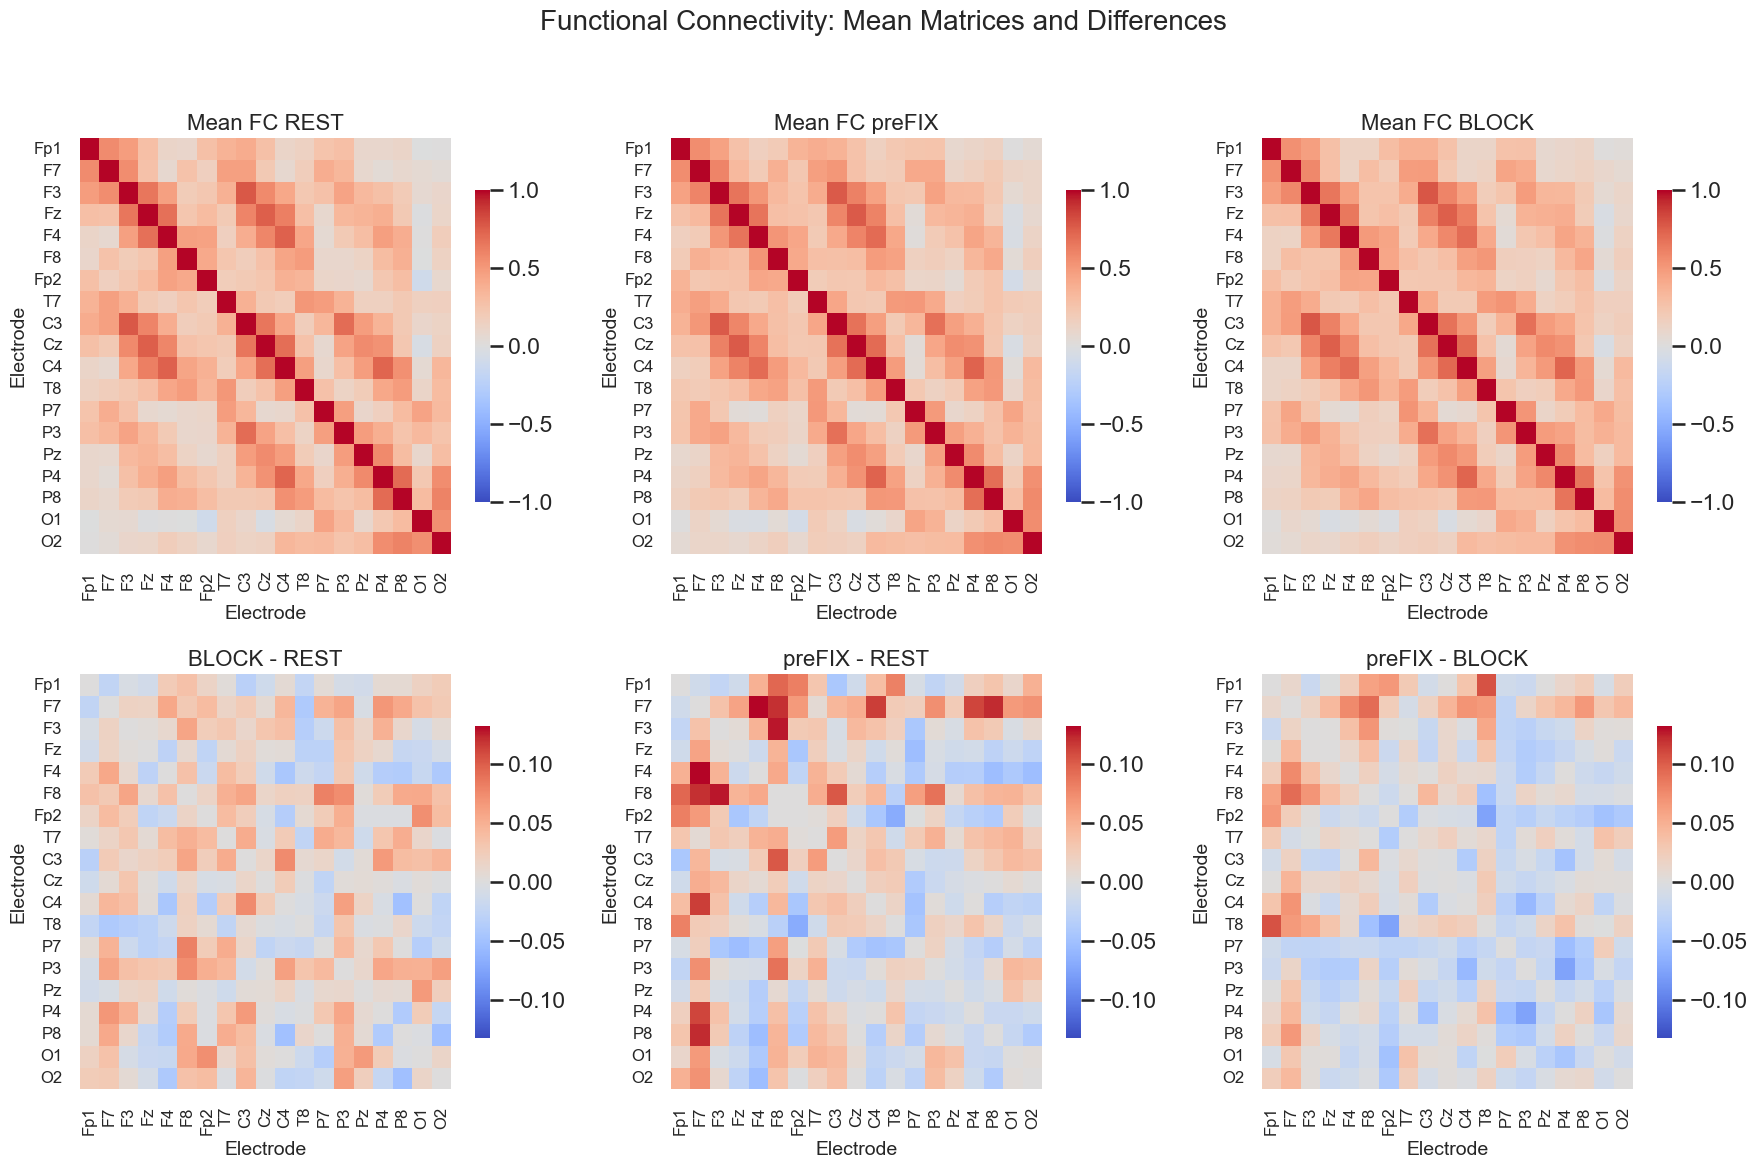

In [34]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Define anatomical order for electrodes
custom_order = ['Fp1', 'F7', 'F3', 'Fz', 'F4', 'F8', 'Fp2',
                'T7', 'C3', 'Cz', 'C4', 'T8',
                'P7', 'P3', 'Pz', 'P4', 'P8',
                'O1', 'O2']

# Compute mean FC across subjects and blocks
def compute_mean_fc(fc_array):
    return np.nanmean(fc_array, axis=(0, 3))  # shape: (electrodes, electrodes)

# Compute mean FC matrices
mean_rest = compute_mean_fc(rest_all)
mean_fix = compute_mean_fc(fix_all)
mean_block = compute_mean_fc(block_all)

# Compute difference matrices
diff_block_rest = mean_block - mean_rest
diff_fix_rest = mean_fix - mean_rest
diff_fix_block = mean_fix - mean_block

# Create a mapping from current electrode order to index
elec_to_idx = {e: i for i, e in enumerate(valid_electrodes_global)}

# Get index order for the custom anatomical order
custom_indices = [elec_to_idx[e] for e in custom_order if e in elec_to_idx]

# Reorder matrices
def reorder_matrix(mat, indices):
    return mat[np.ix_(indices, indices)]

mean_rest = reorder_matrix(mean_rest, custom_indices)
mean_fix = reorder_matrix(mean_fix, custom_indices)
mean_block = reorder_matrix(mean_block, custom_indices)

diff_block_rest = reorder_matrix(diff_block_rest, custom_indices)
diff_fix_rest = reorder_matrix(diff_fix_rest, custom_indices)
diff_fix_block = reorder_matrix(diff_fix_block, custom_indices)

# Update labels
plot_labels = [custom_order[i] for i in range(len(custom_indices))]

# Set color scale limits
vmax_fc = np.max([np.abs(mean_rest).max(), np.abs(mean_fix).max(), np.abs(mean_block).max()])
vmax_diff = np.max([np.abs(diff_block_rest).max(), np.abs(diff_fix_rest).max(), np.abs(diff_fix_block).max()])

# Plot
fig, axes = plt.subplots(2, 3, figsize=(18, 12))

# Top row: FC matrices
fc_matrices = [mean_rest, mean_fix, mean_block]
fc_titles = ['Mean FC REST', 'Mean FC preFIX', 'Mean FC BLOCK']

for ax, fc_mat, title in zip(axes[0], fc_matrices, fc_titles):
    sns.heatmap(fc_mat, ax=ax, cmap='coolwarm', vmin=-1, vmax=1, cbar=True,
                xticklabels=plot_labels, yticklabels=plot_labels,
                cbar_kws={'shrink': 0.75})
    ax.set_title(title, fontsize=16)
    ax.set_xlabel('Electrode', fontsize=14)
    ax.set_ylabel('Electrode', fontsize=14)
    ax.tick_params(labelsize=12)

# Bottom row: Difference matrices
diff_matrices = [diff_block_rest, diff_fix_rest, diff_fix_block]
diff_titles = ['BLOCK - REST', 'preFIX - REST', 'preFIX - BLOCK']

for ax, diff_mat, title in zip(axes[1], diff_matrices, diff_titles):
    sns.heatmap(diff_mat, ax=ax, center=0, cmap='coolwarm', vmin=-vmax_diff, vmax=vmax_diff,
                xticklabels=plot_labels, yticklabels=plot_labels,
                cbar=True, cbar_kws={'shrink': 0.75})
    ax.set_title(title, fontsize=16)
    ax.set_xlabel('Electrode', fontsize=14)
    ax.set_ylabel('Electrode', fontsize=14)
    ax.tick_params(labelsize=12)

plt.suptitle('Functional Connectivity: Mean Matrices and Differences', fontsize=20)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()
